# 09 — Prepare Descriptors for Complex Phase Prediction

Prepares BOP, ACE, and SOAP descriptors for all configurations of the complex TCP phases (R, M, P, δ) to be used in the prediction notebooks.

## Prerequisites / Input files
- `Fe-Mo/Atomsobjects/{R,M,P,delta}_structures.pkl` — structure objects (available on Zenodo)
- `Fe-Mo/Descriptors/PREDICTION_Fe-Mo_{R,M,P,delta}_0.7dprojections_0.5os_table_WUBIND_16.pkl` — pre-computed BOP descriptors (available on Zenodo)

## Outputs
- `Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_*.pkl` — coordination-averaged prediction descriptors

## Notes
> Pre-computed BOP descriptors for the complex phases are provided in the Zenodo archive. Download them before running this notebook.

> ACE and SOAP descriptors for complex phases can be recomputed if `python-ace` and DScribe are available.



# Prepare the structures and the features for R, P, M and $\delta$ phases

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate, old_permutate
import joblib
try:
    from dependencies.bopdftprojections.bopdftprojections.projections import Projections
    _has_bopdftprojection = True
except (ModuleNotFoundError, ImportError):
    _has_bopdftprojection = False
from Tools import PlottingTools as plotting
from Tools.DatasetTools.GeneralFeaturizer import cn_persite
from importlib.machinery import SourceFileLoader
from sklearn.metrics import mean_squared_error
import logging
dataset = 'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
MAG = 0
if MAG == 0:
    target_case = 'EF_nmhcp'
elif MAG == 1:
    target_case = 'EF_fmbcc'

descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')

/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logger = logging.getLogger()
logging.basicConfig( format='%(message)s',level=logging.INFO,)


In [3]:
import shutil

# Enable LaTeX text rendering only if a TeX Live toolchain is available.
required_tex_bins = ("latex", "dvipng", "kpsewhich")
has_texlive = all(shutil.which(cmd) is not None for cmd in required_tex_bins)

plt.rc("text", usetex=has_texlive)
plt.rc("font", family="serif", size=24)
plt.rc("xtick", labelsize=18)
plt.rc("ytick", labelsize=18)
plt.rc("axes", labelsize=18)
figw, figh = plt.rcParams['figure.figsize']

if not has_texlive:
    print(
        "TeX Live not fully available (missing one of: latex, dvipng, kpsewhich). "
        "Using matplotlib internal text rendering."
    )

In [4]:
import logging

In [5]:
from mendeleev import element
from ase import Atoms

In [6]:
import Tools.PredictionTools.MakeAtomsOjects as MAO

In [7]:
SKIP_VIS = 'SKIP_VIS'

In [8]:
DS = Dataset(dataset=dataset, target_name=target_case, remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"')
BS = DS.BS #pd.read_pickle(f'{dataset}/FullyCuratedParsedBriefSummary.pkl')
BS = BS.loc[~BS.index.str.contains('delta')]
TRAIN_RBS = BS.query('Phase == "R"')

In [9]:
BS.filter(regex = "EF")

,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.374554,0.363607,0.351444
...,...,...,...
Fe_pv30.sigma.FM,0.075258,0.075258,0.075258
Fe_pv6.C15.FM,0.144169,0.144169,0.144169
Mo_sv8.A15.NM,0.095306,0.095306,0.095306
Mo_sv6.C15.NM,0.367463,0.367463,0.367463


In [10]:
target_case

'EF_nmhcp'

In [11]:
DS.StructureNames[DS.StructureNames == 'M']

Series([], Name: Phase, dtype: object)

In [12]:
train_features = DS.Features

In [13]:
train_features['atomic']['Structure'].max()

10

In [14]:
train_features['atomic']['Structure'].min()

0

In [15]:
pd.concat([ DS.StructureNames, train_features['atomic']['Structure']], axis =1 ).reset_index(drop=True).drop_duplicates().sort_values('Structure')

,Phase,Structure
162,A15,0
6,C14,1
161,C15,2
0,C36,3
1,R,4
11,chi,6
2,mu,9
3,sigma,10


Text(0, 0.5, '$\\Delta E_F$ (meV/at)')

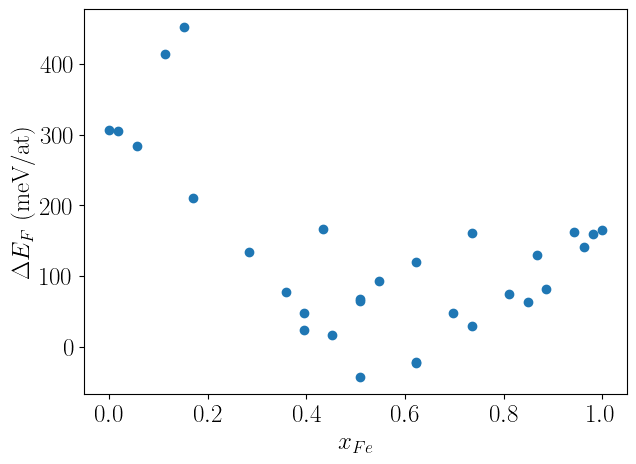

In [16]:
fig, axes = plt.subplots()
axes.scatter(TRAIN_RBS['Fe_pv'], TRAIN_RBS['EF_nmhcp']*1000)
axes.set_xlabel('$x_{Fe}$')
axes.set_ylabel(r'$\Delta E_F$ (meV/at)')

In [17]:
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')
CNList = pd.read_pickle(CNListLocation)

In [18]:
LearningAtomsObjects = pd.read_json('Fe-Mo/Atomsobjects/Fe-Mo-POSCAR.initial-rescaled-AtomsObjects.json').query('index.str.contains("R-.*NM$")')
LearningAtomsObjects['atoms'] = LearningAtomsObjects['atoms'].map(Atoms.fromdict)

In [19]:
AtomsObjects = {'R' :
#                        {'permutations': LearningAtomsObjects.index.str.split('\.').map(lambda s: s[1]),
#                         'atoms_objects_file': os.path.join(dataset,'Atomsobjects/R_structures.pkl')}
                    {'permutations': permutate('R', 2, 11), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/R_structures.pkl')}, 
#                    'R_old':
#                    {'permutations': old_permutate('R', 2, 11), 'atoms_objects_file': os.path.join(dataset, 'Atomsobjects/R_structures_old.pkl')},
                    'P' : 
                    {'permutations': permutate('P', 2, 12), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/P_structures.pkl')},
#                    'P_old' : 
#                    {'permutations': old_permutate('P', 2, 12), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/P_structures.pkl')},
                    'delta': 
                    {'permutations': permutate('delta', 2, 14), 'atoms_objects_file' : os.path.join(dataset,'Atomsobjects/delta_structures.pkl') },
                    'M':
                    {'permutations': permutate('M', 2, 11 ), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects', 'M_structures.pkl' )}
                   }

In [20]:
AtomsObjects['R']['permutations'][0], AtomsObjects['R']['permutations'][-1], 

('R-AAAAAAAAAAA', 'R-BBBBBBBBBBB')

In [21]:
atom_volumes = {'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [22]:
#atom_volumes = MAO.get_atom_volume_from_mp({'Fe' : 'mp-13', 'Mo' : 'mp-129'})
# was taking volumes from MP , but MPRester is not working due to incompatibilities

In [23]:
atom_volumes

{'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [24]:
for name, phase_atoms in AtomsObjects.items():
    print(name)
    if os.path.exists(phase_atoms['atoms_objects_file']):
        phase_atoms['Atoms'] = pd.read_pickle(phase_atoms['atoms_objects_file'])
    else:
        phase_atoms['Atoms'] = make_all_atoms_objects(phase_atoms['permutations'], atom_volumes_def=atom_volumes)
        phase_atoms['Atoms'] = phase_atoms['Atoms'].to_frame()
        phase_atoms['Atoms'].index = phase_atoms['Atoms'].index +'.NM'
        phase_atoms['Atoms'].columns = ['atoms']
        phase_atoms['Atoms'].to_pickle(phase_atoms['atoms_objects_file'])
AtomsObjects['R']['Atoms'].index = AtomsObjects['R']['Atoms'].index.str.replace("-AAAAAAAAAAA", '')
AtomsObjects['R']['Atoms'].index = AtomsObjects['R']['Atoms'].index.str.replace("-BBBBBBBBBBB", '')

R
P
delta
M


In [25]:
AtomsObjects['R']['Atoms']

,atoms
Fe_pv53.R.NM,"(Atom('Fe', [5.614366370550564, 5.130930694031..."
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,"(Atom('Fe', [5.688450365423163, 5.198635545859..."
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,"(Atom('Fe', [5.63927762944244, 5.1536969216767..."
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,"(Atom('Fe', [5.712721111029581, 5.220816412832..."
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,"(Atom('Fe', [5.688450365423163, 5.198635545859..."
...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,"(Atom('Mo', [6.149712932802712, 5.620180224060..."
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,"(Atom('Mo', [6.12878666841063, 5.6010558553976..."
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,"(Atom('Mo', [6.191143463482836, 5.658043300231..."
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,"(Atom('Mo', [6.149712932802712, 5.620180224060..."


In [26]:
len(AtomsObjects['R']['Atoms'].iloc[0].values[0])

53

In [27]:
len(AtomsObjects['M']['Atoms'].iloc[0].values[0])

52

In [28]:
len(AtomsObjects['P']['Atoms'].iloc[0].values[0])

56

In [29]:
len(AtomsObjects['delta']['Atoms'].iloc[0].values[0])

56

## compare atoms objects to the ones used for learning

Text(0.5, 0, 'volume of unit cell in training set')

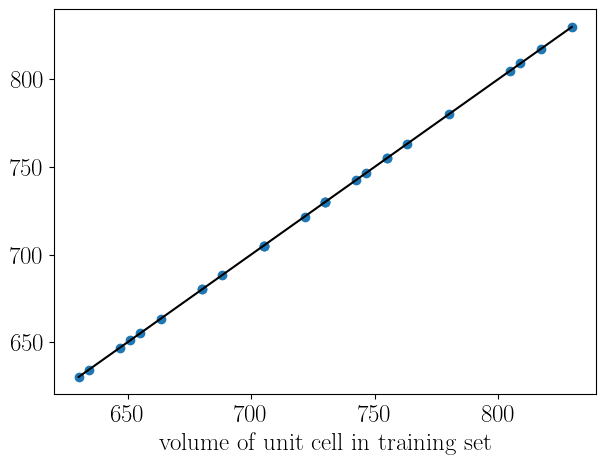

In [30]:
not_created = AtomsObjects['R']['Atoms'].index.difference(LearningAtomsObjects.index)

intersection = LearningAtomsObjects.index.intersection(AtomsObjects['R']['Atoms'].index)

created_intersection_volumes = AtomsObjects['R']['Atoms'].atoms[intersection].map(lambda a: a.get_volume())

#alt_created_intersection_volumes = binaries_predict['R_old']['Atoms'].atoms[intersection].map(lambda a: a.get_volume())


intersection_volumes = LearningAtomsObjects.atoms[intersection].map(lambda a: a.get_volume())

fig, axes = plt.subplots()
axes.scatter(intersection_volumes, created_intersection_volumes)
#axes.scatter(intersection_volumes, alt_created_intersection_volumes)
axes.plot([ created_intersection_volumes.min(), created_intersection_volumes.max() ], [ created_intersection_volumes.min(), created_intersection_volumes.max() ], '-k')
axes.set_xlabel('volume of created unit cell')
axes.set_xlabel('volume of unit cell in training set')

In [31]:
if not SKIP_VIS in os.environ:
    theatoms=AtomsObjects['P']['Atoms'].atoms.sample(n=1).iloc[0]
    plotting.plotly_atoms(theatoms)

In [32]:
if not SKIP_VIS in os.environ:
    theatoms=AtomsObjects['R']['Atoms'].atoms.sample(n=1).iloc[0]
    plotting.plotly_atoms(theatoms)

In [33]:
if not SKIP_VIS in os.environ:
    theatoms=AtomsObjects['delta']['Atoms'].atoms.sample(n=1).iloc[0]
    plotting.plotly_atoms(theatoms)

In [34]:
if not SKIP_VIS in os.environ:
    theatoms=AtomsObjects['M']['Atoms'].atoms.sample(n=1).iloc[0]
    plotting.plotly_atoms(theatoms)

# Make BS 

In [35]:
def get_nelem(a):
    return len(np.unique(a.get_chemical_symbols()))

In [36]:
BS_predict = {}
for name, phaseAtoms in AtomsObjects.items():
    BS_predict[name] = phaseAtoms['Atoms'].atoms.map(len)
    BS_predict[name].name = 'num_atoms'
    compo = pd.DataFrame.from_dict(
        phaseAtoms['Atoms'].atoms.map(lambda a: pd.Series(a.symbols).value_counts().to_dict()).to_dict(),
        orient = 'index'
    ).fillna(0)
    compo['Fe_pv'] = compo['Fe'] / BS_predict[name]
    compo['Mo_sv'] = 1 - compo['Fe_pv']
    compo['Mag'] = MAG #FM
    compo['nelem'] = phaseAtoms['Atoms'].atoms.map(get_nelem)
    BS_predict[name] = pd.concat([BS_predict[name], compo], axis = 1)

In [37]:
BS_predict['R']['Structure'] = 4
#BS_predict['R_old']['Structure'] = 4

In [38]:
BS_predict['P']['Structure'] = 11

In [39]:
BS_predict['delta']['Structure'] = 11

In [40]:
BS_predict['M']['Structure'] = 11

In [41]:
BS.query('Phase == "R"').columns

Index(['', 'V', 'E0', 'B', 'fit', 'xc', 'encut', 'deltak', 'ncrash', 'nelem',
       'B0', 'V0', 'atom_A', 'atom_B', 'num_atom_A', 'num_atom_B', 'num_atoms',
       'Fe_pv', 'Mo_sv', 'Mag', 'Phase', 'EF_fmbcc', 'EF_nmhcp', 'EF_nmfcc'],
      dtype='object')

# LOAD MODELS 

In [42]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_KernelRidge.pkl')

In [43]:
from Tools.DatasetTools.MLConveniences import filter_features

In [44]:
voting_regressor = joblib.load(regressor_file)

# Recover learning predictions

In [45]:
BOP = '0.7dProjections_0.5os'
Bop = '0.7dprojections_0.5os'
ACE = 'ACE'
SOAP = 'SOAP_specific_small'
ModelName = 'Kernel Ridge'
FeatureLabels = {BOP: 'BOP', ACE: 'ACE', SOAP : 'SOAP', Bop: 'BOP'}
TrainingNames = {BOP: '0.7dProjections 0.5OS BOP', ACE: 'ACE', SOAP: 'SOAP_specific_small'}

In [46]:
FeaturesOfInterest = [BOP, ACE, SOAP]

In [47]:
Learning_Predictions = {}
for featurename in FeaturesOfInterest:
    X = DS.Features[TrainingNames[featurename]]#.query('Mag == 0')
    Y = DS.target#[X.index]
    voting_regressor[('Kernel Ridge', TrainingNames[featurename] )].fit(X.astype(float), Y)
    Learning_Predictions[featurename] = voting_regressor[(ModelName, TrainingNames[featurename])].predict(DS.Features[TrainingNames[featurename]].astype(float))#()#DS.Features
    Learning_Predictions[featurename] = pd.Series(Learning_Predictions[featurename], index = DS.Features[TrainingNames[featurename]].index, name = target_case+f'__{featurename}')

In [48]:
DS.Features[TrainingNames[BOP]].loc[DS.Features[TrainingNames[BOP]].index.str.contains('R-')]

,Structure,Mag,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_0_0,moments_0_CN12,...,Binf_0_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,U_bind,U_bond_atom,random
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,0,-12.861017,-3.401887,0.0,-1.518361,-0.685699,-7.255070,-2.226226,-1.402076,...,0.374035,1.009751,0.946518,0.0,1.135645,1.059122,0.991045,-320.368376,-342.957751,0.800017
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,4,0,-15.113474,-4.128102,0.0,-1.741764,-0.717372,-8.526237,-2.007736,-1.183585,...,0.374218,1.092657,1.084320,0.0,1.177525,1.021425,1.051940,-382.000045,-402.467268,0.040341
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,4,0,-17.596018,-5.050195,0.0,-1.777790,-0.861057,-9.906977,-1.789245,-0.965094,...,0.409037,1.184854,1.259212,0.0,1.125330,1.051474,1.133119,-449.451606,-468.146125,0.856835
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,4,0,-18.677780,-5.464652,0.0,-1.866534,-0.906130,-10.440463,-1.716415,-0.892264,...,0.410120,1.212035,1.319548,0.0,1.127063,1.057102,1.107494,-484.840385,-496.736028,0.336069
Fe_pv46Mo_sv7.R-BAAAAAABAAA.NM,4,0,-8.982988,-2.526719,0.0,-5.440459,-0.396953,-0.618857,-3.355094,-1.802642,...,0.371398,0.975065,1.082877,0.0,0.875283,0.979317,0.823128,-235.764245,-240.658675,0.219969
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,4,0,-8.557208,-2.529504,0.0,-0.901821,-0.391391,-4.734492,-3.318679,-1.839057,...,0.301362,1.002401,1.047073,0.0,1.039431,0.804119,0.969704,-217.198003,-229.179272,0.591873
Fe_pv43Mo_sv10.R-ABAAAAAAABB.NM,4,0,-8.453555,-2.471782,0.0,-0.896261,-0.408537,-4.676976,-3.245849,-1.766226,...,0.297341,0.938449,1.006532,0.0,0.875748,0.731646,0.960878,-212.406310,-226.403002,0.723909
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,4,0,-8.447634,-2.470887,0.0,-0.879126,-0.377151,-4.720470,-3.100189,-1.839057,...,0.298099,0.925060,0.916686,0.0,0.863480,0.967960,0.981153,-206.178347,-226.163430,0.122179
Fe_pv37Mo_sv16.R-ABAAAAAABBB.NM,4,0,-8.575102,-2.449052,0.0,-0.922409,-0.425200,-4.778441,-3.027359,-1.766226,...,0.304525,0.898254,0.895879,0.0,0.779566,1.004209,0.962308,-209.780574,-229.503882,0.612469
Fe_pv33Mo_sv20.R-AAAAABAABBB.NM,4,0,-9.414898,-2.601704,0.0,-0.924933,-0.575835,-5.312425,-2.881698,-1.620566,...,0.327071,0.894866,0.882211,0.0,0.707501,1.107911,0.990686,-242.029507,-251.704738,0.876553


In [49]:
LearningRPhase = BS[BS['Phase']=='R'].index

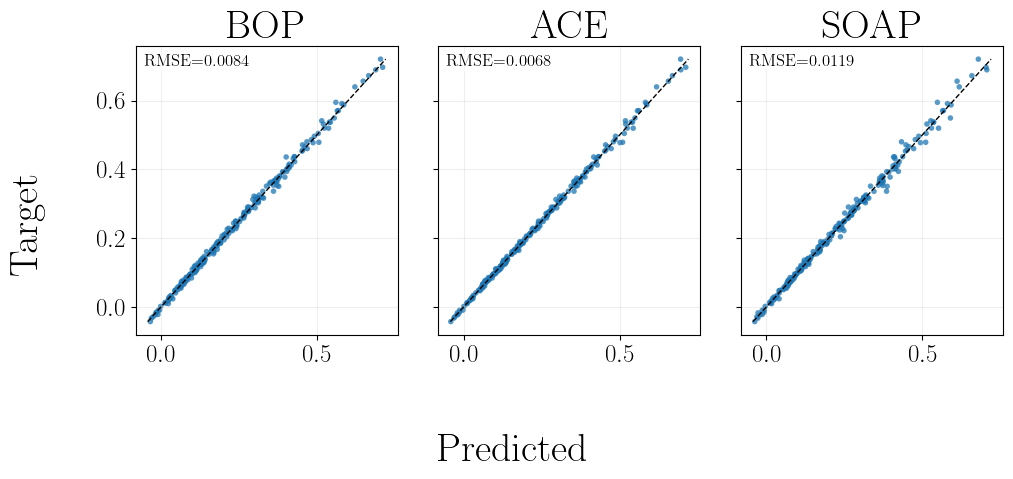

In [50]:
n_panels = len(Learning_Predictions)
ncols = min(3, n_panels)
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(figw * ncols/2, figh  * nrows),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for ax, (featurename, pred_series) in zip(axes.ravel(), Learning_Predictions.items()):
    common_idx = pred_series.index.intersection(DS.target.index)
    x = pred_series.loc[common_idx]
    y = DS.target.loc[common_idx]

    ax.scatter(x, y, s=16, alpha=0.75, edgecolor='none')

    vmin = min(x.min(), y.min())
    vmax = max(x.max(), y.max())
    ax.plot([vmin, vmax], [vmin, vmax], '--k', lw=1.0)

    rmse = mean_squared_error(y.values, x.values, squared=False) #np.sqrt(np.mean((y.values - x.values) ** 2))
    ax.text(
        0.03, 0.97,
        f'RMSE={rmse:.4f}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
    )

    ax.set_title(FeatureLabels[featurename])
    ax.grid(alpha=0.2)

# Hide unused axes if grid is larger than the number of panels.
for ax in axes.ravel()[n_panels:]:
    ax.set_visible(False)

fig.supxlabel('Predicted')
fig.supylabel('Target')
fig.tight_layout()

# CALCULATE FEATURES 

In [51]:
import shutil

In [52]:
elements = dataset.split('-')

## BOP Features 

In [53]:
from BopFoxFeaturizer.Featurizer import BopfoxFeatures
print("bopfoxfeaturizer import OK")
from Tools.DatasetTools.Commoms import *
os.environ['PATH']+=':'+os.path.join(os.getcwd(),'dependencies/bopfox/src/')
from BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures

bopfoxfeaturizer import OK


### Define parameters for BOP

In [54]:
DS.Features.keys()

dict_keys(['atomic', 'dataset', 'SOAP_specific_small', 'ACE', 'Canonical ACE', 'Canonical BOP', '0.7dProjections 0.5OS BOP', 'dataset + Canonical BOP', 'dataset + 0.7dProjections 0.5OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_specific_small no CNAV', 'ACE no CNAV', 'Canonical ACE no CNAV', 'Canonical BOP no CNAV', '0.7dProjections 0.5OS BOP no CNAV', 'dataset + Canonical BOP no CNAV', 'dataset + 0.7dProjections 0.5OS BOP no CNAV'])

In [55]:
globalmoments = 16
model_definitions = {
    '0.7dprojections_0.5os': {'model_maker_options' : {
        'element_pairs_kwargs' : {
            'bond_integral_scale': 0.7,
        },
        'atom_blocks_kwargs': {
            'onsite_levels_scale' : 0.5,
            'select_orbitals' : {'Fe': 'd', 'Mo' : 'd'}
        },
    },
    'moments' : globalmoments
    },
}
cutoff = 'table'
atoms = ['initial', 'relaxed']
retry = False

In [56]:
if _has_bopdftprojection:
    P = Projections()
    P.readbxmodels()
    P.get_bond_chunks()
    P.get_autobonds()
    P.get_all_onsite_levels()
    P.get_restructured_projections()
    def create_modelfile(acompound, target_model_filename, modelname='projections', element_pairs_kwargs={}, atom_blocks_kwargs={} ):
        print(acompound)
        if 'canonical' not in modelname :
            model_filename = P.save_abond_bx(acompound, return_filename=True,
                                            modelname=modelname, 
                                            element_pairs_kwargs=element_pairs_kwargs,
                                            atom_blocks_kwargs=atom_blocks_kwargs)
            print(model_filename)
        else:
            model_filename = C.base_canonical #f'models/W_canonical.bx'
        shutil.copy(model_filename, target_model_filename)
    def replace_symbols(theatoms, replacements=None):
        new_symbols = theatoms.get_chemical_symbols()
        if replacements is not None:
            for original, replacement in replacements.items():
                new_symbols = [s.replace(original, replacement) for s in new_symbols]
        new_atoms = theatoms.copy()
        new_atoms.set_chemical_symbols(new_symbols)
        return new_atoms


### Calculate or load precalculated BOP features

In [57]:
bop_features = {}
bop_features_files = {}

In [58]:
cwd = os.getcwd()
binary = os.path.join(cwd, 'dependencies', 'bopfox','src', 'bopfox')
if os.path.exists(binary):
    _has_bopfox = True

In [59]:
for (model, definition), (phase, atoms_df) in product(model_definitions.items(), AtomsObjects.items()):
    if _has_bopdftprojection:
        if 'moments' in definition.keys():
            thismoments = definition['moments']
        else:
            thismoments = 16
        if (model, thismoments, phase) in bop_features.keys():
            continue
        create_model_options = {}
        if 'model_maker_options' in definition.keys():
            create_model_options.update(definition['model_maker_options'])
    use_elements = copy.copy(elements)
    if _has_bopdftprojection:
        if 'replace atoms' in definition.keys():
            for realelement, targetelement in definition['replace atoms'].items():
                use_elements = set([s.replace(realelement, targetelement) for s in use_elements])
    components = ''.join(use_elements)
    if _has_bopdftprojection:
        modelsfile = os.path.join('models', f'{dataset}-{components}_{model}.bx')
        if not os.path.exists(os.path.dirname(modelsfile)):
            os.makedirs(os.path.dirname(modelsfile))
        create_modelfile(use_elements,modelsfile, modelname=model, **create_model_options,   )
        if 'replace atoms' in definition.keys():
            ApplyOnAtoms = atoms_df['atoms'].apply(replace_symbols, replacements = definition['replace atoms'])
        else:
            ApplyOnAtoms = atoms_df.atoms

    print('atoms: ', phase, 'model: ', model, '  cutoff: ', cutoff, ' moments:', globalmoments)
    bop_features_files[(model, globalmoments, phase)] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}_{phase}_{model}_{cutoff}_WUBIND_{globalmoments}.pkl')
    if not os.path.exists(bop_features_files[(model, globalmoments, phase)]):
        if _has_bopfox:
            BOPC = BopfoxFeatures(
                ApplyOnAtoms,modelsfile, modelname=model,
                cutoffby=cutoff, 
                moments = thismoments,
                binary = binary,
                savelog=False
                )
            BOPC.featurize_dataframe(input_pickle=features, output_pickle=features, max_workers=12)
            bop_features[(model, thismoments, phase)] = BOPC.RESULTS #pd.read_pickle(resultspickle[model]) 
            bop_features[(model, thismoments, phase)].to_pickle(features[(model, thismoments, phase)])
        else: 
            raise Exception('bopfox not installed, install bopfox')
    else:
        bop_features[(model, globalmoments, phase)] = pd.read_pickle(bop_features_files[(model, globalmoments, phase)])

atoms:  R model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
atoms:  P model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
atoms:  delta model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
atoms:  M model:  0.7dprojections_0.5os   cutoff:  table  moments: 16


In [60]:
for (model, thismoments, phase), feature in bop_features.items(): 
    if not feature.index.str.contains('NM$', regex=True).all():
        feature.index = feature.index+'.NM'
        bop_features[(model, globalmoments, phase)].to_pickle(features[(model, globalmoments, phase)])

In [61]:
cn_persite

{'A15': array([14, 14, 14, 14, 14, 14, 12, 12]),
 'C14': array([16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 12]),
 'C15': array([16, 16, 12, 12, 12, 12]),
 'C36': array([16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 12, 12,
        12, 12, 12, 12, 12, 12, 12]),
 'bcc': array([14]),
 'chi': array([16, 16, 16, 16, 16, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]),
 'fcc': array([12]),
 'hcp': array([12, 12]),
 'mu': array([12, 12, 12, 12, 12, 12, 12, 15, 15, 16, 16, 14, 14]),
 'sigma': array([12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 12, 12, 12,
        12, 12, 12, 12, 12, 14, 14, 14, 14, 14, 14, 14, 14]),
 'R': array([12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 14, 14, 14, 14, 14, 14, 14,
        14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16,
        16, 16]),
 'delta': array([15, 15, 15, 15, 15, 15, 15, 15, 1

In [62]:
for name, struc in cn_persite.items():
    print(name, len(struc))

A15 8
C14 12
C15 6
C36 24
bcc 1
chi 29
fcc 1
hcp 2
mu 13
sigma 30
R 53
delta 56
P 56
M 52


In [63]:
for phase, list_of_atoms in AtomsObjects.items():
    print(phase, len(list_of_atoms))

R 3
P 3
delta 3
M 3


 ### CNav for bop

In [64]:
bop_cnav_file = {}

In [65]:
name

'M'

In [66]:
trainingname = {'0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP'}

bop_cnav = {}
for name, feature  in bop_features.items():
    specialcolumns =['U_bind','U_bond_atom', 'modelsfile']#, 'U_bond_atom_list'] 
    bop_cnav_file[name] = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(bop_features_files[name]).replace('pkl', 'csv'))

    CNList = pd.Series([cn_persite[name[-1]]]*len(feature), index=feature.index)

    if os.path.exists(bop_cnav_file[name]):
        bop_cnav[name] = pd.read_csv(bop_cnav_file[name], index_col=0).astype(float)  # for some reason some values are objects
    else:
        columnstoexpand = feature.columns.drop([column for column in specialcolumns if column in feature.columns])
        df = gf.array_expansions(feature.dropna(), columnstoexpand)
        ThisCoordination = CNList[feature.index]
        print(name)
        df = gf.featurize_dataframe(df, ThisCoordination)
        shape_factors = gf.get_shape_factors(df)
        bop_cnav[name] = pd.concat(
            [
                BS_predict[name[-1]][['Mag', 'Structure']].loc[df.index], 
                feature[specialcolumns[:-1]].loc[df.index],
                df, shape_factors
            ],
                axis=1)
        bop_cnav[name].to_csv(bop_cnav_file[name])
    intersection = DS.Features[trainingname[name[0]]].columns.intersection(bop_cnav[name].columns)
    bop_cnav[name] = bop_cnav[name][intersection]

## ACE features

In [67]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator 
from Tools.DatasetTools.ACEDescriptors import default_options_dict as default_options_dict
from pyace import ACEBBasisSet, PyACECalculator

In [68]:
AceConfig = copy.copy(default_options_dict)

In [69]:
AceConfig['elements'] = dataset.split('-')

In [70]:
ace_features = {}
ace_features_files = {}

In [71]:
model = 'ACE'
description = 'lmax=321'

ACEer = MyPyACECalculator(components=components, multispace_basis_config=AceConfig)
acer = MyPyACECalculator(components, multispace_basis_config=AceConfig)

for phase, atoms_df in AtomsObjects.items():
    ApplyOnAtoms = atoms_df['Atoms']
    print('atoms: ', phase, 'model: ', 'ACE')
    ace_features_files[(model, description, phase)] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}_{phase}_{model}_{description}.pkl')
    print('atoms: ', phase, 'model: ', 'ACE', ace_features_files[(model, description, phase)])
    if not os.path.exists(ace_features_files[(model, description, phase)]):
        cwd = os.getcwd()
        ace_features[(model, description, phase)] = acer.featurize_series(atoms_df['Atoms'].atoms)
        ace_features[(model, description, phase)].name = 'ace_projections'
        ace_features[(model, description, phase)] = ace_features[(model, description, phase)].to_frame()
        ace_features[(model, description, phase)].to_pickle(ace_features_files[(model, description, phase)])
    else:
        ace_features[(model, description, phase)] = pd.read_pickle(ace_features_files[(model, description, phase)])
        if isinstance(ace_features[(model, description, phase)], pd.core.series.Series):
            ace_features[(model, description, phase)] = ace_features[(model, description, phase)].to_frame()
            ace_features[(model, description, phase)].columns = ['ace_projections']

atoms:  R model:  ACE
atoms:  R model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_R_ACE_lmax=321.pkl
atoms:  P model:  ACE
atoms:  P model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_P_ACE_lmax=321.pkl
atoms:  delta model:  ACE
atoms:  delta model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_delta_ACE_lmax=321.pkl
atoms:  M model:  ACE
atoms:  M model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_M_ACE_lmax=321.pkl


In [72]:
ace_cnav = {}
ace_cnav_files = {}
trainingname.update({'ACE': 'ACE'})

In [73]:
for (model, descriptor, phase), phase_ace_features in ace_features.items():
#    if 'ACE' not in model:
#        continue
    key = (model, descriptor, phase)
    print(model, descriptor, phase)
    ace_cnav_files[key] = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(ace_features_files[key]).replace('pkl', 'csv'))
    columnstoexpand = phase_ace_features.columns
    CNList = pd.Series([cn_persite[phase]]*len(phase_ace_features), index=phase_ace_features.index)
    if os.path.exists(ace_cnav_files[key]):
        print(phase, 'read ace features from ', ace_cnav_files[key])
        ace_cnav[key] = pd.read_csv(ace_cnav_files[key], index_col = 0)
    else:
        print(phase,  'calculate cnav ace features  ')
        expanded_ace = gf.array_expansions(phase_ace_features, ['ace_projections'])
        ace_cnav[key] = gf.featurize_dataframe(expanded_ace, CNList)
        ace_cnav[key].to_csv(ace_cnav_files[key])

    intersection = DS.Features[trainingname[key[0]]].columns.intersection(ace_cnav[key].columns)
    ace_cnav[key] = ace_cnav[key][intersection]

ACE lmax=321 R
R read ace features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_R_ACE_lmax=321.csv
ACE lmax=321 P
P read ace features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_P_ACE_lmax=321.csv
ACE lmax=321 delta
delta read ace features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_delta_ACE_lmax=321.csv
ACE lmax=321 M
M read ace features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_M_ACE_lmax=321.csv


## load SOAP

In [74]:
soapcases = ['specific']

In [75]:
from dscribe.descriptors import SOAP
from mendeleev import element
import ase
from sklearn.feature_selection import VarianceThreshold

In [76]:
soap_features = {}
soap_features_files={}

In [77]:
soap_params = dict(
    r_cut = 4,
    n_max = 5,
    l_max = 4, # f
    sigma = 0.1,
    rbf = 'gto',
    periodic = True,
)
model = 'SOAP'
param_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])
description = 'specific_small'
trainingname.update({(model, description): 'SOAP_specific_small'})

species = [element(s).atomic_number for s in dataset.split('-')]

In [78]:


for phase, atoms_df in AtomsObjects.items():
    ApplyOnAtoms = atoms_df['Atoms']
    print('atoms: ', phase, 'model: ', model)
    soap_features_files[(model, description, phase)] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}_{phase}_{model}_{description}.pkl')
    print('atoms: ', phase, 'model: ', 'ACE', soap_features_files[(model, description, phase)])
    if  not os.path.exists(soap_features_files[(model, description, phase)]):
        cwd = os.getcwd()
        SOAPER = SOAP(species=species, **soap_params)
        soap_features[(model, description, phase)] = ApplyOnAtoms.atoms.map(SOAPER.create)
        soap_features[(model, description, phase)].name = model
        soap_features[(model, description, phase)] = soap_features[(model, description, phase)].to_frame()
        soap_features[(model, description, phase)].to_pickle(soap_features_files[(model, description, phase)])
    else:
        soap_features[(model, description, phase)] = pd.read_pickle(soap_features_files[(model, description, phase)])
        if isinstance(soap_features[(model, description, phase)], pd.core.series.Series):
            soap_features[(model, description, phase)] = soap_features[(model, description, phase)].to_frame()
            soap_features[(model, description, phase)].columns = [f'{model}_{description}']

atoms:  R model:  SOAP
atoms:  R model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_R_SOAP_specific_small.pkl
atoms:  P model:  SOAP
atoms:  P model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_P_SOAP_specific_small.pkl
atoms:  delta model:  SOAP
atoms:  delta model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_delta_SOAP_specific_small.pkl
atoms:  M model:  SOAP
atoms:  M model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_M_SOAP_specific_small.pkl


In [79]:
soap_cnav = {}
soap_cnav_files = {}
trainingname.update({'SOAP': 'SOAP_specific_small'})

In [80]:
for (model, descriptor, phase), phase_soap_features in soap_features.items():
#    if 'soap' not in model:
#        continue
    key = (model, descriptor, phase)
    print(model, descriptor, phase)
    soap_cnav_files[key] = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(soap_features_files[key]).replace('pkl', 'csv'))
    columnstoexpand = phase_soap_features.columns
    CNList = pd.Series([cn_persite[phase]]*len(phase_soap_features), index=phase_soap_features.index)
    if os.path.exists(soap_cnav_files[key]):
        print(phase, 'read soap features from ', soap_cnav_files[key])
        soap_cnav[key] = pd.read_csv(soap_cnav_files[key], index_col = 0)
    else:
        print(phase,  'calculate cnav soap features  ')
        expanded_soap = gf.array_expansions(phase_soap_features, [model])
        soap_cnav[key] = gf.featurize_dataframe(expanded_soap, CNList)
        soap_cnav[key].to_csv(soap_cnav_files[key])
    intersection = DS.Features[trainingname[key[0]]].columns.intersection(soap_cnav[key].columns)
    soap_cnav[key] = soap_cnav[key][intersection]

SOAP specific_small R
R read soap features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_R_SOAP_specific_small.csv
SOAP specific_small P
P read soap features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_P_SOAP_specific_small.csv
SOAP specific_small delta
delta read soap features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_delta_SOAP_specific_small.csv
SOAP specific_small M
M read soap features from  Fe-Mo/Descriptors/CNAV_PREDICTION_Fe-Mo_M_SOAP_specific_small.csv


## update featurescnav

In [81]:
featurescnav = {}
featurescnav.update(bop_cnav)
featurescnav.update(ace_cnav)
featurescnav.update(soap_cnav)

In [82]:
featurescnav.keys()

dict_keys([('0.7dprojections_0.5os', 16, 'R'), ('0.7dprojections_0.5os', 16, 'P'), ('0.7dprojections_0.5os', 16, 'delta'), ('0.7dprojections_0.5os', 16, 'M'), ('ACE', 'lmax=321', 'R'), ('ACE', 'lmax=321', 'P'), ('ACE', 'lmax=321', 'delta'), ('ACE', 'lmax=321', 'M'), ('SOAP', 'specific_small', 'R'), ('SOAP', 'specific_small', 'P'), ('SOAP', 'specific_small', 'delta'), ('SOAP', 'specific_small', 'M')])

In [83]:
for key, featurecnav in featurescnav.items():
    print(key)
    if 'Mag' not in featurecnav.columns:
        featurescnav[key] = pd.concat([ BS_predict[key[-1]]['Mag'].astype(float), featurescnav[key] ], axis=1)
    if 'Structure' not in featurecnav.columns: 
        featurescnav[key] = pd.concat([ BS_predict[key[-1]]['Structure'].astype(float), featurescnav[key] ], axis = 1)

('0.7dprojections_0.5os', 16, 'R')
('0.7dprojections_0.5os', 16, 'P')
('0.7dprojections_0.5os', 16, 'delta')
('0.7dprojections_0.5os', 16, 'M')
('ACE', 'lmax=321', 'R')
('ACE', 'lmax=321', 'P')
('ACE', 'lmax=321', 'delta')
('ACE', 'lmax=321', 'M')
('SOAP', 'specific_small', 'R')
('SOAP', 'specific_small', 'P')
('SOAP', 'specific_small', 'delta')
('SOAP', 'specific_small', 'M')


In [84]:
for key, featurecnav in featurescnav.items():
    print(key)
    if 'Mag' not in featurecnav.columns:
        print('Mag no')
    else:
        print('Mag yea')
    if 'Structure' not in featurecnav.columns: 
        print('Structure no')
    else:
        print('Structure yea')

('0.7dprojections_0.5os', 16, 'R')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'P')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'delta')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'M')
Mag yea
Structure yea
('ACE', 'lmax=321', 'R')
Mag yea
Structure yea
('ACE', 'lmax=321', 'P')
Mag yea
Structure yea
('ACE', 'lmax=321', 'delta')
Mag yea
Structure yea
('ACE', 'lmax=321', 'M')
Mag yea
Structure yea
('SOAP', 'specific_small', 'R')
Mag yea
Structure yea
('SOAP', 'specific_small', 'P')
Mag yea
Structure yea
('SOAP', 'specific_small', 'delta')
Mag yea
Structure yea
('SOAP', 'specific_small', 'M')
Mag yea
Structure yea


# Prediction ! 

In [85]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV')])

In [86]:
ModelName = 'Kernel Ridge'
trainingname = { '0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP', 'ACE': 'ACE', 'SOAP': 'SOAP_specific_small' }

In [87]:
featurescnav.keys()

dict_keys([('0.7dprojections_0.5os', 16, 'R'), ('0.7dprojections_0.5os', 16, 'P'), ('0.7dprojections_0.5os', 16, 'delta'), ('0.7dprojections_0.5os', 16, 'M'), ('ACE', 'lmax=321', 'R'), ('ACE', 'lmax=321', 'P'), ('ACE', 'lmax=321', 'delta'), ('ACE', 'lmax=321', 'M'), ('SOAP', 'specific_small', 'R'), ('SOAP', 'specific_small', 'P'), ('SOAP', 'specific_small', 'delta'), ('SOAP', 'specific_small', 'M')])

In [88]:
# NumPy 1.26 deprecates np.find_common_type; some sklearn/pandas paths still trigger it.
Prediction_Values = {}
bag_of_predictions = {}
ERR = {}
model_alias = {'SOAP': 'SOAP_specific_small', 'specific': 'SOAP_specific_small'}
Accepted_Prediction_Values = {}
remove_fraction = 0.015
force_terminal_compositions = True
terminal_tol = 1e-12

for (modelkey, modelparam, phase), featurecnav in featurescnav.items():
    lookup_key = model_alias.get(modelkey, modelkey)

#    logger.info("%s, %s, %s, %s, MAG = %d" %(  modelkey, modelparam, phase, ModelLabels[lookup_key], MAG ))
    X = DS.Features[trainingname[modelkey]]#.query('Mag == 0')
    Y = DS.target#[X.index]
    voting_regressor[('Kernel Ridge', trainingname[modelkey])].fit(X.astype(float), Y)
    prediction_values_location = os.path.join(dataset,'results',f'PREDICTION__{phase}__{lookup_key}_{modelparam}_MAG={MAG}.csv')
    combi = (ModelName, trainingname[modelkey])

    Prediction_Values[lookup_key, phase] = pd.Series(voting_regressor[combi].predict(featurecnav.astype(float)), index=featurecnav.index, name=f'{target_case}__{lookup_key}').to_frame()

    bag_of_predictions[combi] = []
    for i, (name, estimator) in enumerate(voting_regressor[combi].named_estimators_.items()):
        Prediction_Values[lookup_key, phase][f'vote_{i}']  =pd.Series(estimator.predict(featurecnav.astype(float)), index = featurecnav.index)

    Prediction_Values[lookup_key, phase]['std_votes'] = Prediction_Values[lookup_key, phase].filter(regex='vote_[0-9]+').std(axis=1)
    Prediction_Values[lookup_key, phase].to_csv(prediction_values_location)

    n_total = len(Prediction_Values[lookup_key, phase])
    n_remove = int(np.floor(remove_fraction * n_total))
    n_keep = n_total - n_remove
    accepted = Prediction_Values[lookup_key, phase].nsmallest(n_keep, 'std_votes')

    if force_terminal_compositions:
        phase_composition = BS_predict[phase]['Fe_pv']
        terminal_idx = phase_composition[
            np.isclose(phase_composition, 0.0, atol=terminal_tol)
            | np.isclose(phase_composition, 1.0, atol=terminal_tol)
        ].index
        terminal_idx = Prediction_Values[lookup_key, phase].index.intersection(terminal_idx)
        if len(terminal_idx) > 0:
            accepted = pd.concat(
                [accepted, Prediction_Values[lookup_key, phase].loc[terminal_idx]],
                axis=0,
            )
            accepted = accepted[~accepted.index.duplicated(keep='first')]

    Accepted_Prediction_Values[lookup_key, phase] = accepted

    # Effective threshold used for this (feature, phase): max accepted ensemble std.
    ERR[(lookup_key, phase)] = Accepted_Prediction_Values[lookup_key, phase]['std_votes'].max()

threshold_table = pd.Series(ERR, name='std_votes_threshold').rename_axis(index=['feature', 'phase']).to_frame()
threshold_by_feature = threshold_table.groupby(level='feature').max().rename(columns={'std_votes_threshold': 'max_std_votes_threshold'})
threshold_by_feature

,max_std_votes_threshold
feature,
0.7dprojections_0.5os,0.185949
ACE,0.331104
SOAP_specific_small,0.073633


In [89]:
Accepted_Prediction_Values[Bop, 'R'][Accepted_Prediction_Values[Bop, 'R'].index.str.contains('Mo_sv53|Fe_pv53')]

,EF_nmhcp__0.7dprojections_0.5os,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,vote_11,std_votes
Mo_sv53.R.NM,0.306517,0.298972,0.308711,0.304831,0.308594,0.306882,0.315228,0.310173,0.308477,0.313641,0.309901,0.285941,0.306851,0.007674
Fe_pv53.R.NM,0.293319,0.315692,0.427635,0.270528,0.569729,0.167152,0.076583,0.220558,0.273923,0.393861,0.243384,0.241394,0.319391,0.127922


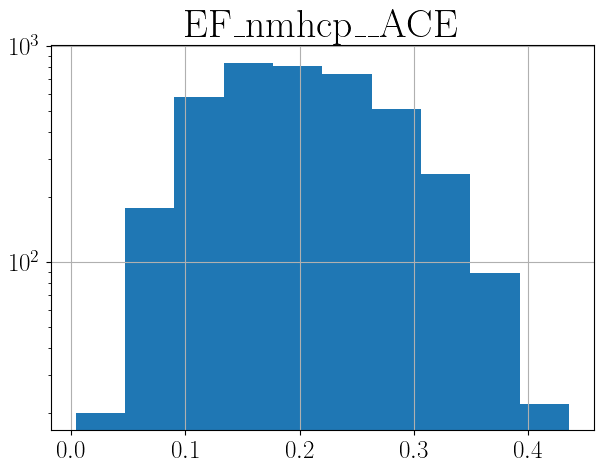

In [90]:
ax = Accepted_Prediction_Values['ACE', 'P'].hist('EF_nmhcp__ACE')
ax[0, 0].set_yscale('log')

In [91]:
colors = {
    'R': 'blue', 
    'M': 'teal', 
    'P': 'red',
    'delta': 'purple'
}

Text(0, 0.5, 'density counts')

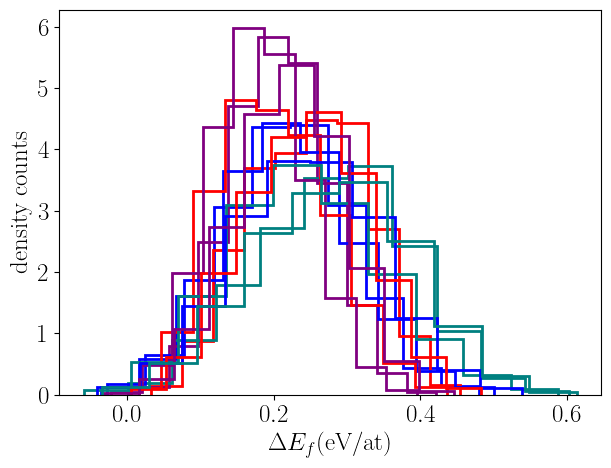

In [92]:
fig, axes = plt.subplots()
for key, serie in Prediction_Values.items():
    axes.hist(Accepted_Prediction_Values[key][f'{target_case}__{key[0]}'], histtype='step', color=colors[key[-1]], linewidth=2, density=True)
axes.set_xlabel(r'$\Delta E_f $(eV/at)')
axes.set_ylabel('density counts')

In [93]:
select_model = '0.7dprojections_0.5os'

In [94]:
coincidence = Prediction_Values[(select_model, 'R')][f'{target_case}__{select_model}'].index.intersection(TRAIN_RBS.index)

In [95]:
difference =TRAIN_RBS.index.difference(coincidence)

In [96]:
TRAIN_RBS.loc[difference]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,1,52,53,0.018868,0.981132,NM,R,0.307309,0.305966,0.304474
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076915,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,52,1,53,0.981132,0.018868,NM,R,0.228834,0.159020,0.081452


In [97]:
BS_predict.keys()

dict_keys(['R', 'P', 'delta', 'M'])

In [98]:
labels = {'R': '$R$', 'M': '$M$', 'P': '$P$', 'delta': r'$\delta$'}

In [99]:
Prediction_Values.keys() 

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP_specific_small', 'R'), ('SOAP_specific_small', 'P'), ('SOAP_specific_small', 'delta'), ('SOAP_specific_small', 'M')])

Text(0.5, 0.01, '$x_{Fe}$')

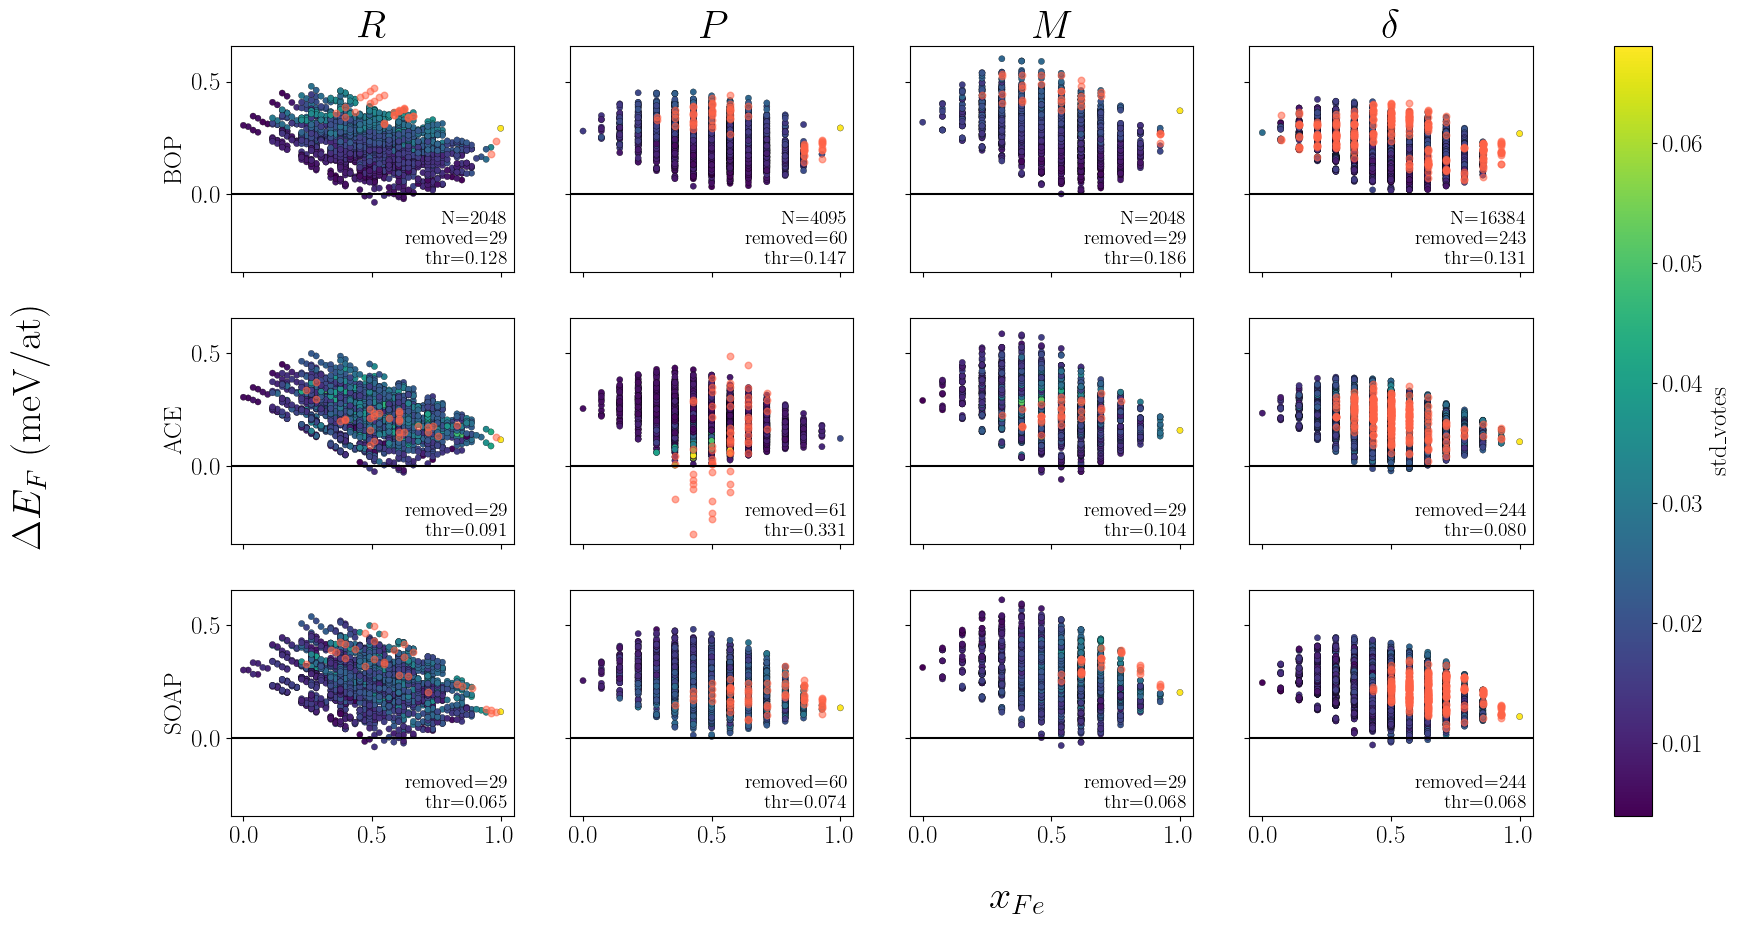

In [100]:
featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
phase_pos = {'R': 0, 'P': 1, 'M': 2, 'delta': 3}
fig, axes = plt.subplots(
    len(FeaturesOfInterest), len(BS_predict),
    figsize = (plt.rcParams['figure.figsize'][0]*3,plt.rcParams['figure.figsize'][1]*2),
    sharey=True, sharex=True)

scatter_mappable = None
for (featurename, phase), prediction in Prediction_Values.items():
    if featurename not in featurename_pos or phase not in phase_pos:
        continue

    I = featurename_pos[featurename]
    J = phase_pos[phase]
    accepted = Accepted_Prediction_Values[(featurename, phase)]

    # Accepted samples: color by voting std.
    accepted_intersection = BS_predict[phase]['Fe_pv'].index.intersection(accepted.index)
    scatter_mappable = axes[I, J].scatter(
        BS_predict[phase]['Fe_pv'][accepted_intersection],
        accepted.loc[accepted_intersection, f'{target_case}__{featurename}'],
        c=accepted.loc[accepted_intersection, 'std_votes'],
        cmap='viridis',
        s=20,
        edgecolor='k',
        linewidth=0.2,
    )

    # Removed samples: present in full predictions but filtered out by uncertainty cutoff.
    removed_idx = prediction.index.difference(accepted.index)
    removed_intersection = BS_predict[phase]['Fe_pv'].index.intersection(removed_idx)
    if len(removed_intersection) > 0:
        axes[I, J].scatter(
            BS_predict[phase]['Fe_pv'][removed_intersection],
            prediction.loc[removed_intersection, f'{target_case}__{featurename}'],
            color='tomato',
            s=22,
            alpha=0.55,
            label='removed',
        )

    # Multiline panel label in lower-right with larger font for readability.
    n_total = len(prediction)
    n_removed = len(removed_idx)
    threshold = accepted['std_votes'].max()
    if I == 0:
        panel_label = f'N={n_total}\nremoved={n_removed}\nthr={threshold:.3f}'
    else:
        panel_label = f'removed={n_removed}\nthr={threshold:.3f}'

    axes[I, J].text(
        0.98, 0.02,
        panel_label,
        transform=axes[I, J].transAxes,
        ha='right',
        va='bottom',
        fontsize=14,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2.0),
    )

    if I == 0:
        axes[I, J].set_title(labels[phase])
    if J == 0:
        axes[I, J].set_ylabel(FeatureLabels[ featurename ])
    else:
        axes[I, J].set_ylabel('')
    axes[I, J].axhline(c='k')

if scatter_mappable is not None:
    fig.colorbar(scatter_mappable, ax=axes.ravel().tolist(), label='std_votes')

fig.supylabel(r'$\Delta E_F$ (meV/at)')
fig.supxlabel(r'$x_{Fe}$')

In [101]:
intersection = featurescnav[('ACE', 'lmax=321', 'R')].index.intersection(DS.Features['ACE'].index)

In [102]:
featurescnav[('ACE', 'lmax=321', 'R')].loc[intersection] - DS.Features['ACE'].loc[intersection]

,Mag,Structure,ace_projections_0_0,ace_projections_0_CN12,ace_projections_0_CN13,ace_projections_0_CN14,ace_projections_0_CN15,ace_projections_0_CN16,ace_projections_100_0,ace_projections_100_CN12,...,ace_projections_99_CN14,ace_projections_99_CN15,ace_projections_99_CN16,ace_projections_9_0,ace_projections_9_CN12,ace_projections_9_CN13,ace_projections_9_CN14,ace_projections_9_CN15,ace_projections_9_CN16,random
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.0,0.0,-1.261680e-07,-1.817691e-01,0.0,1.259377e-01,5.583141e-02,1.032186e-08,-1.530663e-09,-7.133928e-02,...,-4.813789e-02,-2.127447e-02,-7.351900e-11,1.253344e-08,8.022419e-01,0.0,-5.197843e-01,-2.824575e-01,-8.788430e-09,NaN
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,0.0,0.0,8.381926e-08,-3.686739e-08,0.0,-1.364842e-08,7.701648e-09,-3.366575e-09,8.233016e-09,-1.224271e-09,...,6.738097e-10,9.165140e-11,1.015216e-10,1.868470e-10,-2.259549e-08,0.0,7.443300e-09,4.838004e-09,5.501033e-09,NaN
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.0,0.0,-1.424136e-07,-1.157040e-02,0.0,-4.092617e-03,5.807568e-03,9.855449e-03,5.987043e-09,3.854402e-02,...,6.417892e-03,7.127778e-03,1.216855e-05,-8.733620e-09,2.201592e-01,0.0,-1.352708e-02,-1.207634e-02,-1.945557e-01,NaN
Fe_pv33Mo_sv20.R-AAAAAABABBB.NM,0.0,0.0,1.998505e-08,7.066307e-08,0.0,3.291430e-08,1.131246e-09,5.527643e-08,1.711331e-08,-3.843237e-10,...,3.317528e-10,-1.883781e-10,-8.732980e-11,-1.531982e-08,-3.799213e-09,0.0,8.348456e-09,1.003109e-08,-9.900162e-09,NaN
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.0,0.0,7.993630e-08,-4.018980e-08,0.0,-1.281134e-01,4.546858e-02,8.264485e-02,1.553546e-08,3.723565e-09,...,-3.293963e-02,2.314172e-02,9.797916e-03,1.507717e-08,-1.306843e-08,0.0,3.499234e-01,-1.420516e-01,-2.078718e-01,NaN
Fe_pv33Mo_sv20.R-AAAAABAABBB.NM,0.0,0.0,-2.751669e-08,-5.208473e-08,0.0,-1.618977e-08,2.963337e-09,7.794473e-09,9.083220e-09,9.817190e-10,...,-2.397007e-09,-5.295490e-11,1.288082e-10,1.810106e-08,1.651387e-08,0.0,-1.038057e-08,-5.825125e-09,-2.207113e-09,NaN
Fe_pv27Mo_sv26.R-AAAAABBABBB.NM,0.0,0.0,-5.994321e-08,2.749378e-08,0.0,5.872391e-09,-8.445907e-10,7.535213e-09,-1.218030e-08,-7.970189e-09,...,2.008175e-09,5.820120e-11,4.107671e-10,9.463144e-09,2.480977e-09,0.0,-3.001606e-09,-7.989575e-09,1.973348e-09,NaN
Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM,0.0,0.0,6.666207e-08,-8.451462e-09,0.0,-4.143516e-10,2.692022e-09,2.835858e-09,-9.624963e-09,9.064346e-09,...,-1.403938e-10,-6.228489e-10,-3.247277e-10,5.038949e-08,-1.350075e-10,0.0,6.175557e-10,2.472876e-09,-5.965931e-09,NaN
Fe_pv39Mo_sv14.R-AAAABAAAABB.NM,0.0,0.0,-3.290393e-08,2.183419e-08,0.0,8.898266e-09,-2.412324e-09,8.775938e-09,2.115691e-09,-2.787716e-10,...,4.497909e-10,-3.809917e-10,-1.440771e-09,2.682887e-09,6.868013e-09,0.0,3.571830e-09,-3.022966e-09,5.266010e-09,NaN
Fe_pv29Mo_sv24.R-AAAABABABAB.NM,0.0,0.0,-4.293642e-08,9.375122e-09,0.0,4.078935e-08,-9.402161e-09,1.630128e-08,1.797744e-08,5.411869e-09,...,2.060086e-09,1.182330e-10,-1.130457e-09,-8.025659e-09,1.344169e-09,0.0,3.937534e-09,8.220849e-09,8.471789e-09,NaN


In [103]:
DS.Features['SOAP_specific_small'].astype(float)

,Structure,Mag,SOAP_0_0,SOAP_0_CN12,SOAP_0_CN13,SOAP_0_CN14,SOAP_0_CN15,SOAP_0_CN16,SOAP_1_0,SOAP_1_CN12,...,SOAP_272_0,SOAP_272_CN12,SOAP_272_CN14,SOAP_273_0,SOAP_273_CN12,SOAP_273_CN14,SOAP_274_0,SOAP_274_CN12,SOAP_274_CN14,random
Fe_pv4Mo_sv20.C36-ABBBB.FM,3.0,1.0,0.003273,7.762930e-08,0.0,0.000000e+00,0.000000e+00,3.272556e-03,0.000104,-2.922527e-07,...,0.000083,0.000076,0.000000e+00,-0.000081,-0.000076,0.000000e+00,0.000081,0.000077,0.000000e+00,0.920218
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4.0,0.0,0.005558,5.558122e-03,0.0,2.019407e-08,2.232171e-08,6.814435e-08,0.000167,1.677100e-04,...,0.000090,0.000050,2.618440e-05,-0.000076,-0.000043,-2.191570e-05,0.000065,0.000038,1.864383e-05,0.800017
Fe_pv2Mo_sv11.mu-BBABB.FM,9.0,1.0,0.003031,2.298952e-08,0.0,3.538836e-08,3.031081e-03,0.000000e+00,0.000076,-8.877701e-08,...,0.000040,0.000029,6.655614e-06,-0.000040,-0.000033,-4.831588e-06,0.000043,0.000038,3.507453e-06,0.661800
Fe_pv8Mo_sv22.sigma-BBBAB.NM,10.0,0.0,0.005236,5.236308e-03,0.0,8.255308e-08,2.649228e-08,0.000000e+00,0.000163,1.639021e-04,...,0.000117,0.000032,7.648500e-05,-0.000105,-0.000026,-7.218032e-05,0.000098,0.000022,7.033538e-05,0.680917
Fe_pv2Mo_sv11.mu-BBBBA.NM,9.0,0.0,0.003021,1.780541e-08,0.0,3.021414e-03,3.538836e-08,1.776818e-09,0.000094,-7.284032e-08,...,0.000059,0.000056,6.034860e-08,-0.000060,-0.000057,-5.608902e-08,0.000062,0.000061,5.222131e-08,0.493009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv29.chi.FM,6.0,1.0,0.000000,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,...,0.000033,0.000007,0.000000e+00,-0.000028,-0.000005,0.000000e+00,0.000025,0.000006,0.000000e+00,0.210061
Fe_pv4Mo_sv2.C15-A2B.FM,2.0,1.0,0.013035,6.517984e-03,0.0,0.000000e+00,0.000000e+00,6.517398e-03,0.000457,2.272736e-04,...,0.000107,0.000061,0.000000e+00,-0.000078,-0.000044,0.000000e+00,0.000057,0.000032,0.000000e+00,0.556271
Fe_pv8Mo_sv16.C36-BAABB.NM,3.0,0.0,0.006573,3.283984e-03,0.0,0.000000e+00,0.000000e+00,3.288754e-03,0.000155,8.212914e-05,...,0.000143,0.000132,0.000000e+00,-0.000141,-0.000133,0.000000e+00,0.000142,0.000137,0.000000e+00,0.717247
Mo_sv8.A15.NM,0.0,0.0,0.000000,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,...,0.000086,0.000023,6.302621e-05,-0.000082,-0.000023,-5.914129e-05,0.000082,0.000024,5.797607e-05,0.728578


In [104]:
from sklearn.metrics import r2_score, mean_squared_error

In [105]:
from scipy.stats import pearsonr, linregress

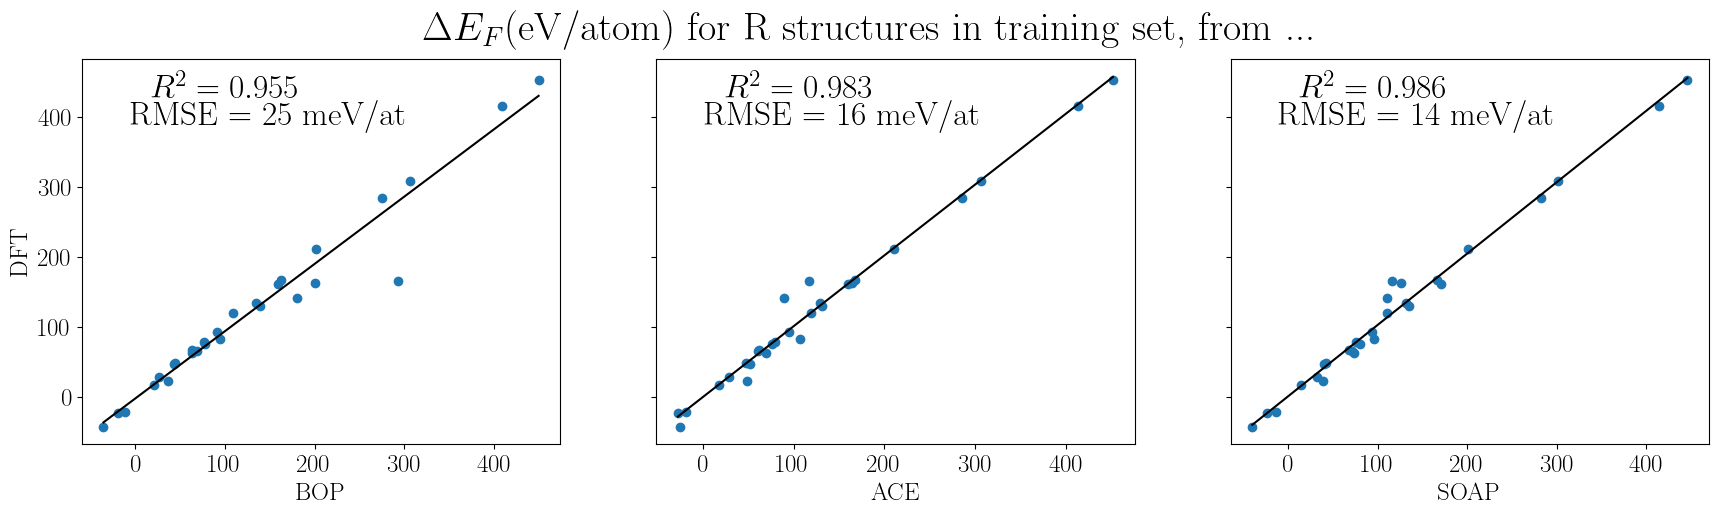

In [106]:
featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label ={'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP' }
phase_pos = {'R': 0}#, 'R_old': 1, 'P': 2, 'delta': 3, 'M': 4}
fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*len(featurename_pos), plt.rcParams['figure.figsize'][1]), sharey = True)
for (featuregroup, I), ax in zip(featurename_pos.items(), axes):
    test_split_samples = BS.index.intersection(BS_predict['R'].index)
    targetname = f'{target_case}__{featuregroup}'
    x = Prediction_Values[(featuregroup, 'R')][targetname][test_split_samples]*1000
    y = BS.loc[test_split_samples][target_case]*1000
    reg = np.polyfit(x, y, 1)
    pol = np.poly1d(reg)
    r2 = r2_score(y, pol(x))
    rmse = mean_squared_error(y, pol(x), squared=False)
    ax.scatter(x, y) 
    ax.plot([x.min(), x.max()], pol([x.min(), x.max()]), 'k')
    ax.annotate (rf'$R^2 = {r2:.3f}$\newline RMSE = {rmse:.0f} meV/at', (0.1, 0.9), xycoords='axes fraction')
    ax.set_xlabel(featurename_label[featuregroup])
axes[0].set_ylabel('DFT')
fig.suptitle(r'$\Delta E_F $(eV/atom) for R structures in training set, from ...')
fig.savefig('Fe-Mo/graphs/Rstructs_Prediction_Vs_DFT.pdf')

In [107]:
BS_predict['P'][BS_predict['P']['Fe_pv'] == 0]

,num_atoms,Fe,Mo,Fe_pv,Mo_sv,Mag,nelem,Structure
Mo_sv56.P-BBBBBBBBBBBB.NM,56,0.0,56.0,0.0,1.0,0,1,11


In [108]:
Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP_specific_small', 'R'), ('SOAP_specific_small', 'P'), ('SOAP_specific_small', 'delta'), ('SOAP_specific_small', 'M')])

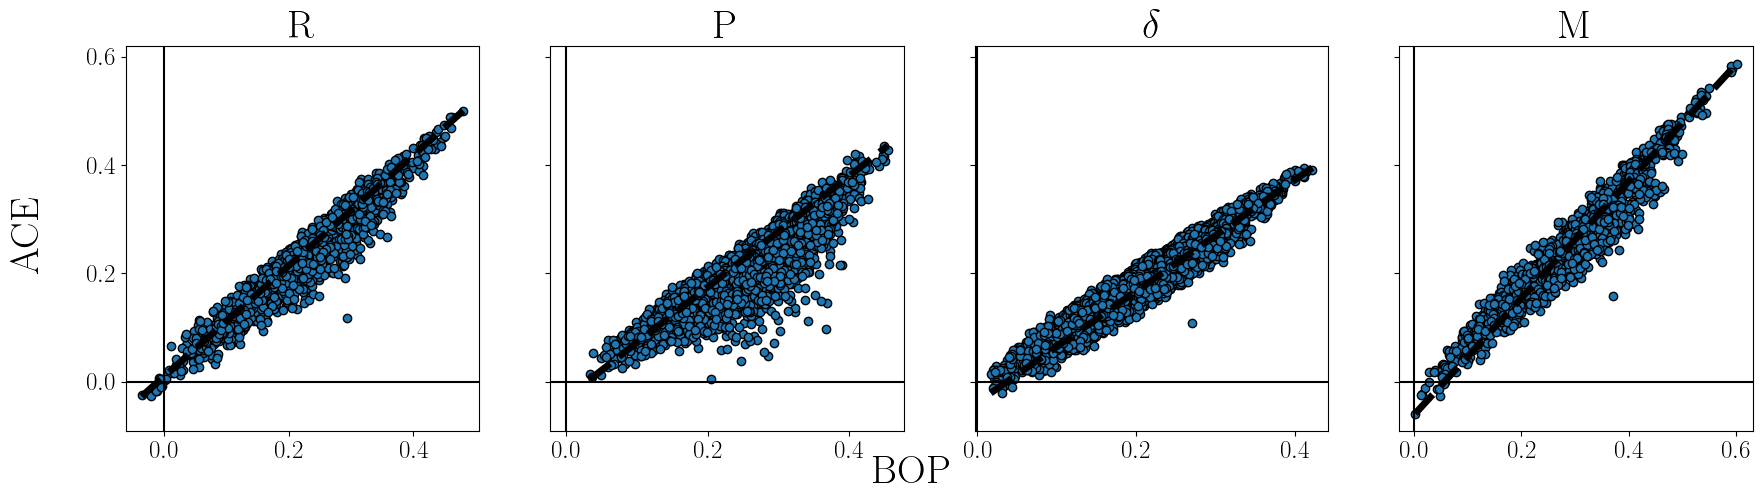

In [109]:
#featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1}
phase_pos = {'R': 0, 'P': 2, 'delta': 3, 'M': 4}#, 'R_old': 1}
phase_label = {'R': 'R', 'P': 'P', 'delta': r'$\delta$', 'M': 'M'}
bopmodel = '0.7dprojections_0.5os'
acemodel = 'ACE'
fig, axes = plt.subplots(
    1, len(phase_pos),
    figsize = (plt.rcParams['figure.figsize'][0]*3,plt.rcParams['figure.figsize'][1]),
    sharey=True)
for phase, axes  in zip(phase_pos, axes):
    if phase == 'R_old':
        continue
    intersection = Accepted_Prediction_Values[(bopmodel, phase)].index.intersection(Accepted_Prediction_Values[(acemodel, phase)].index)
    x = Accepted_Prediction_Values[(bopmodel, phase)][target_case+'__'+bopmodel][intersection]
    y = Accepted_Prediction_Values[(acemodel, phase)][target_case+'__'+acemodel].loc[intersection]
    axes.scatter(x,y,edgecolor='k')
    axes.plot([x.min(), x.max()], [y.min(), y.max()], '--k', lw=5)
    axes.set_title(phase_label[phase])
    axes.axhline(c='k')
    axes.axvline(c='k')

fig.supxlabel('BOP', y=-0.01)
fig.supylabel(acemodel, x=0.07)
fig.savefig('Fe-Mo/graphs/Fe-Mo-PredictionDifferences.pdf')

# Predicted convex hulls 

In [110]:
from Tools.DatasetTools.Tools import Plotting, PlottingChulls
from scipy.spatial import ConvexHull
from matplotlib.lines import Line2D

In [111]:
for (model, phase), prediction_values in Prediction_Values.items() :
    if (target_case, model) not in BS_predict[phase].columns:
        BS_predict[phase] = pd.concat([BS_predict[phase], prediction_values], axis = 1)

In [112]:
BS_predict.keys()#['R'].filter(regex=target_case)

dict_keys(['R', 'P', 'delta', 'M'])

In [113]:
phasesloc= {'R':0, 'M': 1,'P':2 ,'delta':3}
targetsloc = {target_name: i for i, target_name in enumerate(BS_predict['R'].filter(regex='EF_nmhcp').columns)}

In [114]:
feature_labels = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP'}

In [115]:
phase_labels = {'delta': r'$\delta$', 'R': '$R$', 'M': '$M$', 'P': '$P$'}

In [116]:
experimental_range = {
    'sigma': [0.4,0.55],
    'R' : [0.6,0.65],
    'mu' : [0.6, 0.55],
    'lambda': [0.655, 0.66]
}

In [117]:
x = experimental_range['R']

In [118]:
BS_predict[phase].filter(regex='EF_')#columns#['Fe_pv', target_name, 'nelem']

,EF_nmhcp__0.7dprojections_0.5os,EF_nmhcp__ACE,EF_nmhcp__SOAP_specific_small
Fe_pv52.M-AAAAAAAAAAA.NM,0.371118,0.158836,0.201766
Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM,0.269746,0.143309,0.170669
Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM,0.191077,0.133326,0.160137
Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM,0.118155,0.096306,0.114102
Fe_pv48Mo_sv4.M-AAAAAAAABAA.NM,0.229509,0.160696,0.187816
...,...,...,...
Fe_pv4Mo_sv48.M-BBBBBBBBABB.NM,0.368127,0.358419,0.391426
Fe_pv8Mo_sv44.M-BBBBBBBBBAA.NM,0.486684,0.460243,0.478854
Fe_pv4Mo_sv48.M-BBBBBBBBBAB.NM,0.403813,0.376055,0.390795
Fe_pv4Mo_sv48.M-BBBBBBBBBBA.NM,0.400924,0.382040,0.399372


In [119]:
P = Plotting()
inchull = {}
opo_chull = {}
CHULLS = {}

for target_name, J in targetsloc.items():
    featurename = target_name.replace(f'{target_case}__', '')
    CHULLS[target_name] = {}

    for phase, I in phasesloc.items():
#        accepted_key = (featurename, phase)
#        if accepted_key not in Accepted_Prediction_Values:
#            continue
#        accepted_predictions = Accepted_Prediction_Values[accepted_key]
#        if target_name not in accepted_predictions.columns:
#            continue

        # Build plottable set from accepted predictions only, plus composition metadata.
        accepted_predictions = Accepted_Prediction_Values[featurename, phase].index
        plottable = pd.concat(
            [
                BS_predict[phase][['Fe_pv', 'nelem']].loc[accepted_predictions],
                Accepted_Prediction_Values[featurename, phase][[target_name]],
            ],
            axis=1,
        ).dropna(axis=0).sort_values(by=['Fe_pv', target_name])

        if len(plottable) < 3:
            continue

        chull = P.get_convex_hulls(
            {phase: plottable}, ['Fe_pv'], getproperty=target_name, viewpoint=(0.0, -100)
        )
        CHULLS[target_name].update(chull)

        all_vertices_low = np.unique(np.hstack(chull[phase].simplices[chull[phase].good]))
        inchull[(phase, target_name)] = plottable.iloc[all_vertices_low].sort_values(by='Fe_pv')

print(f'Generated convex hulls from accepted predictions for {len(CHULLS)} targets and {len(phasesloc)} phases.')

Generated convex hulls from accepted predictions for 3 targets and 4 phases.


In [120]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [121]:
Accepted_Prediction_Values['0.7dprojections_0.5os', 'R']

,EF_nmhcp__0.7dprojections_0.5os,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,vote_11,std_votes
Fe_pv37Mo_sv16.R-ABAAAAAABBB.NM,0.044174,0.042858,0.044623,0.047233,0.046546,0.041413,0.049953,0.048752,0.041164,0.040344,0.043463,0.037440,0.046300,0.003729
Fe_pv19Mo_sv34.R-ABAABABBBBB.NM,0.077063,0.073319,0.075299,0.077883,0.080628,0.070389,0.085117,0.078810,0.076615,0.073504,0.075231,0.080174,0.077781,0.003924
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,0.025999,0.019676,0.030232,0.023363,0.027359,0.030263,0.027608,0.030413,0.020912,0.028100,0.029334,0.019577,0.025149,0.004160
Fe_pv4Mo_sv49.R-BABBBBBBBAB.NM,0.321250,0.320358,0.321089,0.315678,0.329463,0.327118,0.317749,0.325159,0.321402,0.324037,0.323170,0.313624,0.316147,0.004833
Fe_pv25Mo_sv28.R-ABAABAABBBB.NM,0.089327,0.085646,0.090166,0.086819,0.089974,0.079867,0.090215,0.089576,0.102608,0.089534,0.085571,0.090951,0.090998,0.005285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM,0.351847,0.394294,0.343048,0.263898,0.385577,0.473166,0.209184,0.319796,0.394623,0.388842,0.323519,0.348009,0.378205,0.068464
Fe_pv33Mo_sv20.R-ABBBBAAAAAA.NM,0.373005,0.429844,0.329188,0.258578,0.376114,0.452324,0.284164,0.338317,0.428352,0.402494,0.315902,0.476683,0.384099,0.068561
Fe_pv28Mo_sv25.R-BAABBBBAAAA.NM,0.327533,0.334828,0.289372,0.276422,0.281823,0.358702,0.237615,0.304895,0.330625,0.351398,0.298900,0.511718,0.354101,0.068629
Fe_pv33Mo_sv20.R-ABBAABABAAA.NM,0.269876,0.259705,0.226888,0.226416,0.220884,0.287226,0.209578,0.222998,0.279612,0.298558,0.243472,0.463694,0.299482,0.069040


In [122]:
inchull['R', 'EF_nmhcp__0.7dprojections_0.5os' ]

,Fe_pv,nelem,EF_nmhcp__0.7dprojections_0.5os
Mo_sv53.R.NM,0.000000,1,0.306517
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,0.358491,2,0.054470
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,2,-0.035427
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,2,-0.019714
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,0.735849,2,0.018959
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.849057,2,0.063693
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.886792,2,0.094343
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM,0.943396,2,0.155586
Fe_pv53.R.NM,1.000000,1,0.293319


## save chulls to csv

In [123]:
for (phase, pred__model), chulldata in inchull.items():
    phase_chull_location = os.path.join(ValidationDataLocation, 'inchull', phase)
    os.makedirs(phase_chull_location, exist_ok=True)
    chull_data_loc = os.path.join(phase_chull_location, f'{ pred__model }.csv')
    chulldata.to_csv(chull_data_loc)

## save uncertainties to csv

In [124]:
for (pred__model, phase), predictionvotes in Prediction_Values.items():
    phase_chull_location = os.path.join(ValidationDataLocation, 'inchull', phase)
    os.makedirs(phase_chull_location, exist_ok=True)
    votes_data_loc = os.path.join(phase_chull_location, f'{ pred__model }:votes.csv')
    predictionvotes.to_csv(votes_data_loc)

# Recover samples in convex hull for validation 

In [125]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [126]:
AtomsObjects['P']['Atoms']['atoms']

Fe_pv56.P-AAAAAAAAAAAA.NM           (Atom('Fe', [6.270229734538574, 1.143494556032...
Fe_pv48Mo_sv8.P-AAAAAAAAAAAB.NM     (Atom('Fe', [6.37428511215705, 1.1624710150889...
Fe_pv48Mo_sv8.P-AAAAAAAAAABA.NM     (Atom('Fe', [6.37428511215705, 1.1624710150889...
Fe_pv40Mo_sv16.P-AAAAAAAAAABB.NM    (Atom('Fe', [6.475049825186255, 1.180847359444...
Fe_pv52Mo_sv4.P-AAAAAAAAABAA.NM     (Atom('Fe', [6.322685545287342, 1.153060861664...
                                                          ...                        
Fe_pv4Mo_sv52.P-BBBBBBBBBABB.NM     (Atom('Mo', [6.893805521683064, 1.257215352249...
Fe_pv16Mo_sv40.P-BBBBBBBBBBAA.NM    (Atom('Mo', [6.7599451321235, 1.23280338758266...
Fe_pv8Mo_sv48.P-BBBBBBBBBBAB.NM     (Atom('Mo', [6.849765450381988, 1.249183815301...
Fe_pv8Mo_sv48.P-BBBBBBBBBBBA.NM     (Atom('Mo', [6.849765450381988, 1.249183815301...
Mo_sv56.P-BBBBBBBBBBBB.NM           (Atom('Mo', [6.9372899823230005, 1.26514556312...
Name: atoms, Length: 4096, dtype: object

In [127]:
if not os.path.exists(ValidationDataLocation):
    os.makedirs(ValidationDataLocation)
for (phase, target_name), inchullist in inchull.items():
    group_loc = os.path.join(ValidationDataLocation, 'inchull', phase)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    #inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['Atoms']['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, direct=True, format='vasp')
        validation_structure_location = validation_atoms_location.replace('vasp', 'cfg')
        atoms.write(validation_structure_location, format='cfg')

In [128]:
inchull[('M', 'EF_nmhcp__ACE')]

,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv52.M-BBBBBBBBBBB.NM,0.000000,1,0.291397
Fe_pv24Mo_sv28.M-AABAABBBBBB.NM,0.461538,2,-0.026911
Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM,0.538462,2,-0.058918
Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM,0.615385,2,-0.024443
Fe_pv52.M-AAAAAAAAAAA.NM,1.000000,1,0.158836


In [129]:
inchull[('P', 'EF_nmhcp__ACE')]

,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv56.P-BBBBBBBBBBBB.NM,0.000000,1,0.255457
Fe_pv20Mo_sv36.P-ABBBBABABBAB.NM,0.357143,2,0.003970
Fe_pv28Mo_sv28.P-AAABBBBAABAB.NM,0.500000,2,0.012935
Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM,0.928571,2,0.086428
Fe_pv56.P-AAAAAAAAAAAA.NM,1.000000,1,0.122877


In [130]:
inchull[('R', 'EF_nmhcp__ACE')]

,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv53.R.NM,0.000000,1,0.306008
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,2,0.048849
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,2,-0.024561
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,2,-0.027469
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,0.962264,2,0.089447
Fe_pv53.R.NM,1.000000,1,0.117144


In [131]:
inchull[('delta', 'EF_nmhcp__ACE')]

,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv56.delta-BBBBBBBBBBBBBB.NM,0.000000,1,0.235321
Fe_pv20Mo_sv36.delta-BBBBBBBBABAAAA.NM,0.357143,2,0.019056
Fe_pv24Mo_sv32.delta-BBBBBBBBAAAAAA.NM,0.428571,2,-0.011371
Fe_pv28Mo_sv28.delta-BBBABBBBAAAAAA.NM,0.500000,2,-0.021200
Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM,0.571429,2,-0.011545
Fe_pv36Mo_sv20.delta-BBBAAABBAAAAAA.NM,0.642857,2,0.003752
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,1.000000,1,0.108180


## Plot predicted CHULL

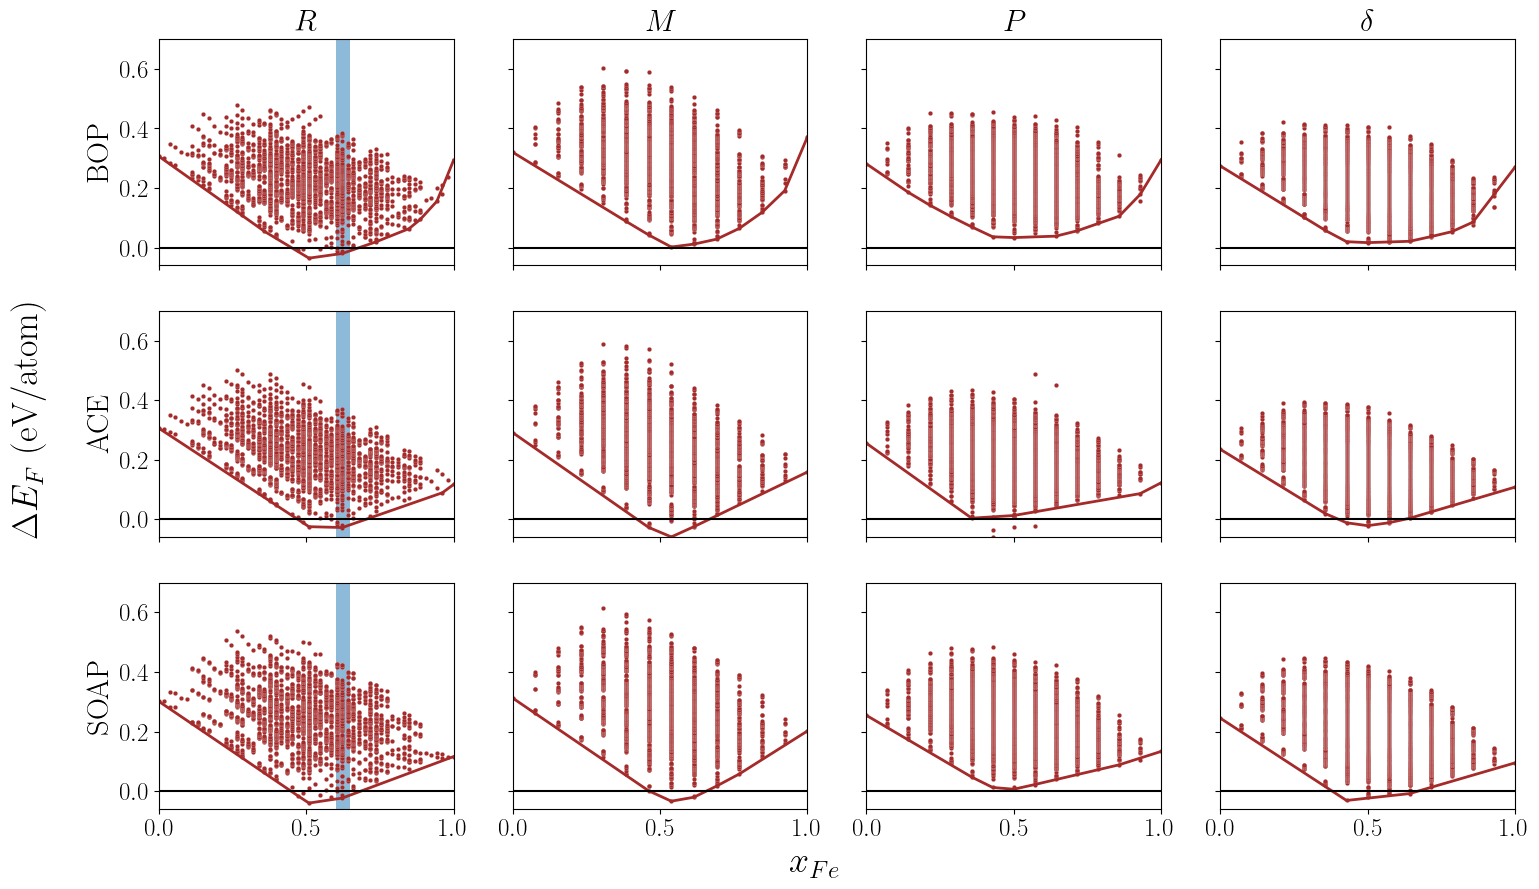

In [132]:
figsize = plt.rcParams['figure.figsize']
fig, axes = plt.subplots(
    len(targetsloc), len(phasesloc),
    sharey=True, sharex=True,
    figsize=(figsize[0] * 2.5, figsize[1] * 2),
)

for target_name, J in targetsloc.items():
    featurename = target_name.replace(target_case + '__', '')
    axes[J, 0].set_ylabel(feature_labels[featurename], fontsize=22)

    for phase, I in phasesloc.items():
        plottable = BS_predict[phase][['Fe_pv', target_name, 'nelem']].dropna(axis=0).sort_values(by=['Fe_pv', target_name])

        if phase == 'R':
            axes[J, I].fill_between(experimental_range[phase], -0.1, 0.7, alpha=0.5)

        axes[J, I].scatter(
            plottable['Fe_pv'].values, plottable[target_name].values,
            c='brown', s=10, lw=0.1, edgecolor='w'
        )
        axes[0, I].set_title(phase_labels[phase], fontsize=22)

        l = axes[J, I].plot(
            inchull[(phase, target_name)]['Fe_pv'].values,
            inchull[(phase, target_name)][target_name].values,
            '-', color='brown', label='chull', linewidth=2
        )

        axes[J, I].axhline(c='k')
        axes[J, I].set_ylim([-0.06, 0.7])
        axes[J, I].set_xlim([0, 1])

fig.subplots_adjust(wspace=0.2, hspace=0.2)
fig.supylabel(r'$\Delta E_F$ (eV/atom)', x=0.04, fontsize=26)
fig.supxlabel('$x_{Fe}$', fontsize=26, y=0.04)
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_compare_predictions.pdf')
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_compare_predictions.png', dpi=300)

## R chull with uncertainties

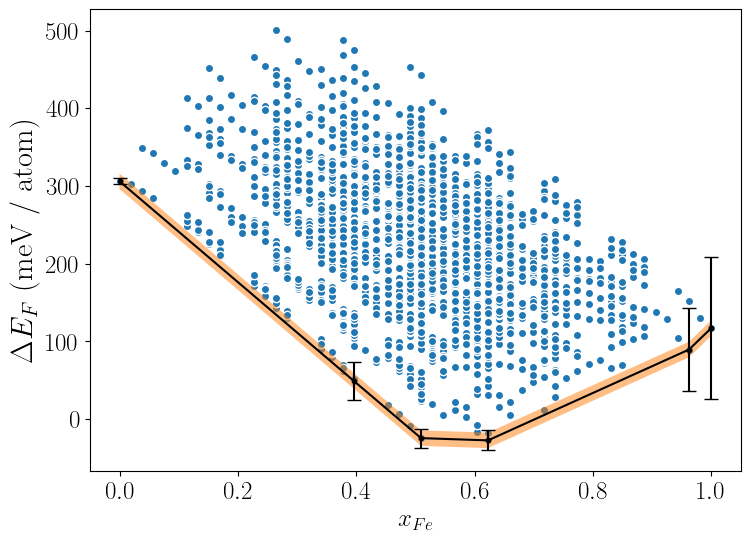

In [133]:
featurename_pos = {'ACE':1}#{'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE',  'SOAP_specific_small': 'SOAP'}
test_errors = {'0.7dprojections_0.5os': 0.018, 'ACE':0.010, 'SOAP_specific_small': 0.015}#?
phase_pos = {'R': 0,} # 'M': 1, 'P': 2, 'delta': 3}#, 'M': 4}
ncols = int(len(phase_pos))
nrows = int(len(featurename_pos))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(plt.rcParams['figure.figsize'][0]*ncols*1.2,plt.rcParams['figure.figsize'][1]*nrows*1.2),
    sharey=True,
    sharex=True
    )
for featuregroup, I in featurename_pos.items():
    targetname = f'{target_case}__{featuregroup}'
    for phase, J in phase_pos.items():
        training_samples = BS.index.str.contains(f'\\.{phase}-')
        index1 = BS_predict[phase].index
        index2 = Prediction_Values[(featuregroup, phase)].index
        intersection = index1.intersection(index2)
        targetname = f'{target_case}__{featuregroup}'
        this_chull = inchull[(phase, targetname)].index
        axes.scatter(BS_predict[phase]['Fe_pv'][intersection], Prediction_Values[(featuregroup, phase)][targetname][intersection]*1000, label = 'Predictions', edgecolor='w')
        axes.plot(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            'k',
            label = 'convex hull'
            )
        axes.fill_between(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 - test_errors[featuregroup]*1000, 
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 + test_errors[featuregroup]*1000, 
            label = 'test error',
            alpha=0.5
            )
        axes.errorbar(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            yerr= Prediction_Values[(featuregroup, phase)]['std_votes'][this_chull].values*1000,
            fmt='.k',
            capsize=5,
#            lolims=True,
            label = 'std from bag of predictions'
            )
        if len(training_samples) <0:
            continue
#        axes.set_title(phase_label[phase], fontsize=22)
#    axes.set_ylabel(featurename_label[featuregroup], fontsize=22)
axes.set_xlabel('$x_{Fe}$')#, fontsize=24)
axes.set_ylabel(rf'$\Delta E_F$ (meV / atom)', fontsize=22)
fig.savefig(f'{dataset}/graphs/{dataset}_R_{targetname}_convexhull.pdf')

## Predicted CHULLs with uncertainties

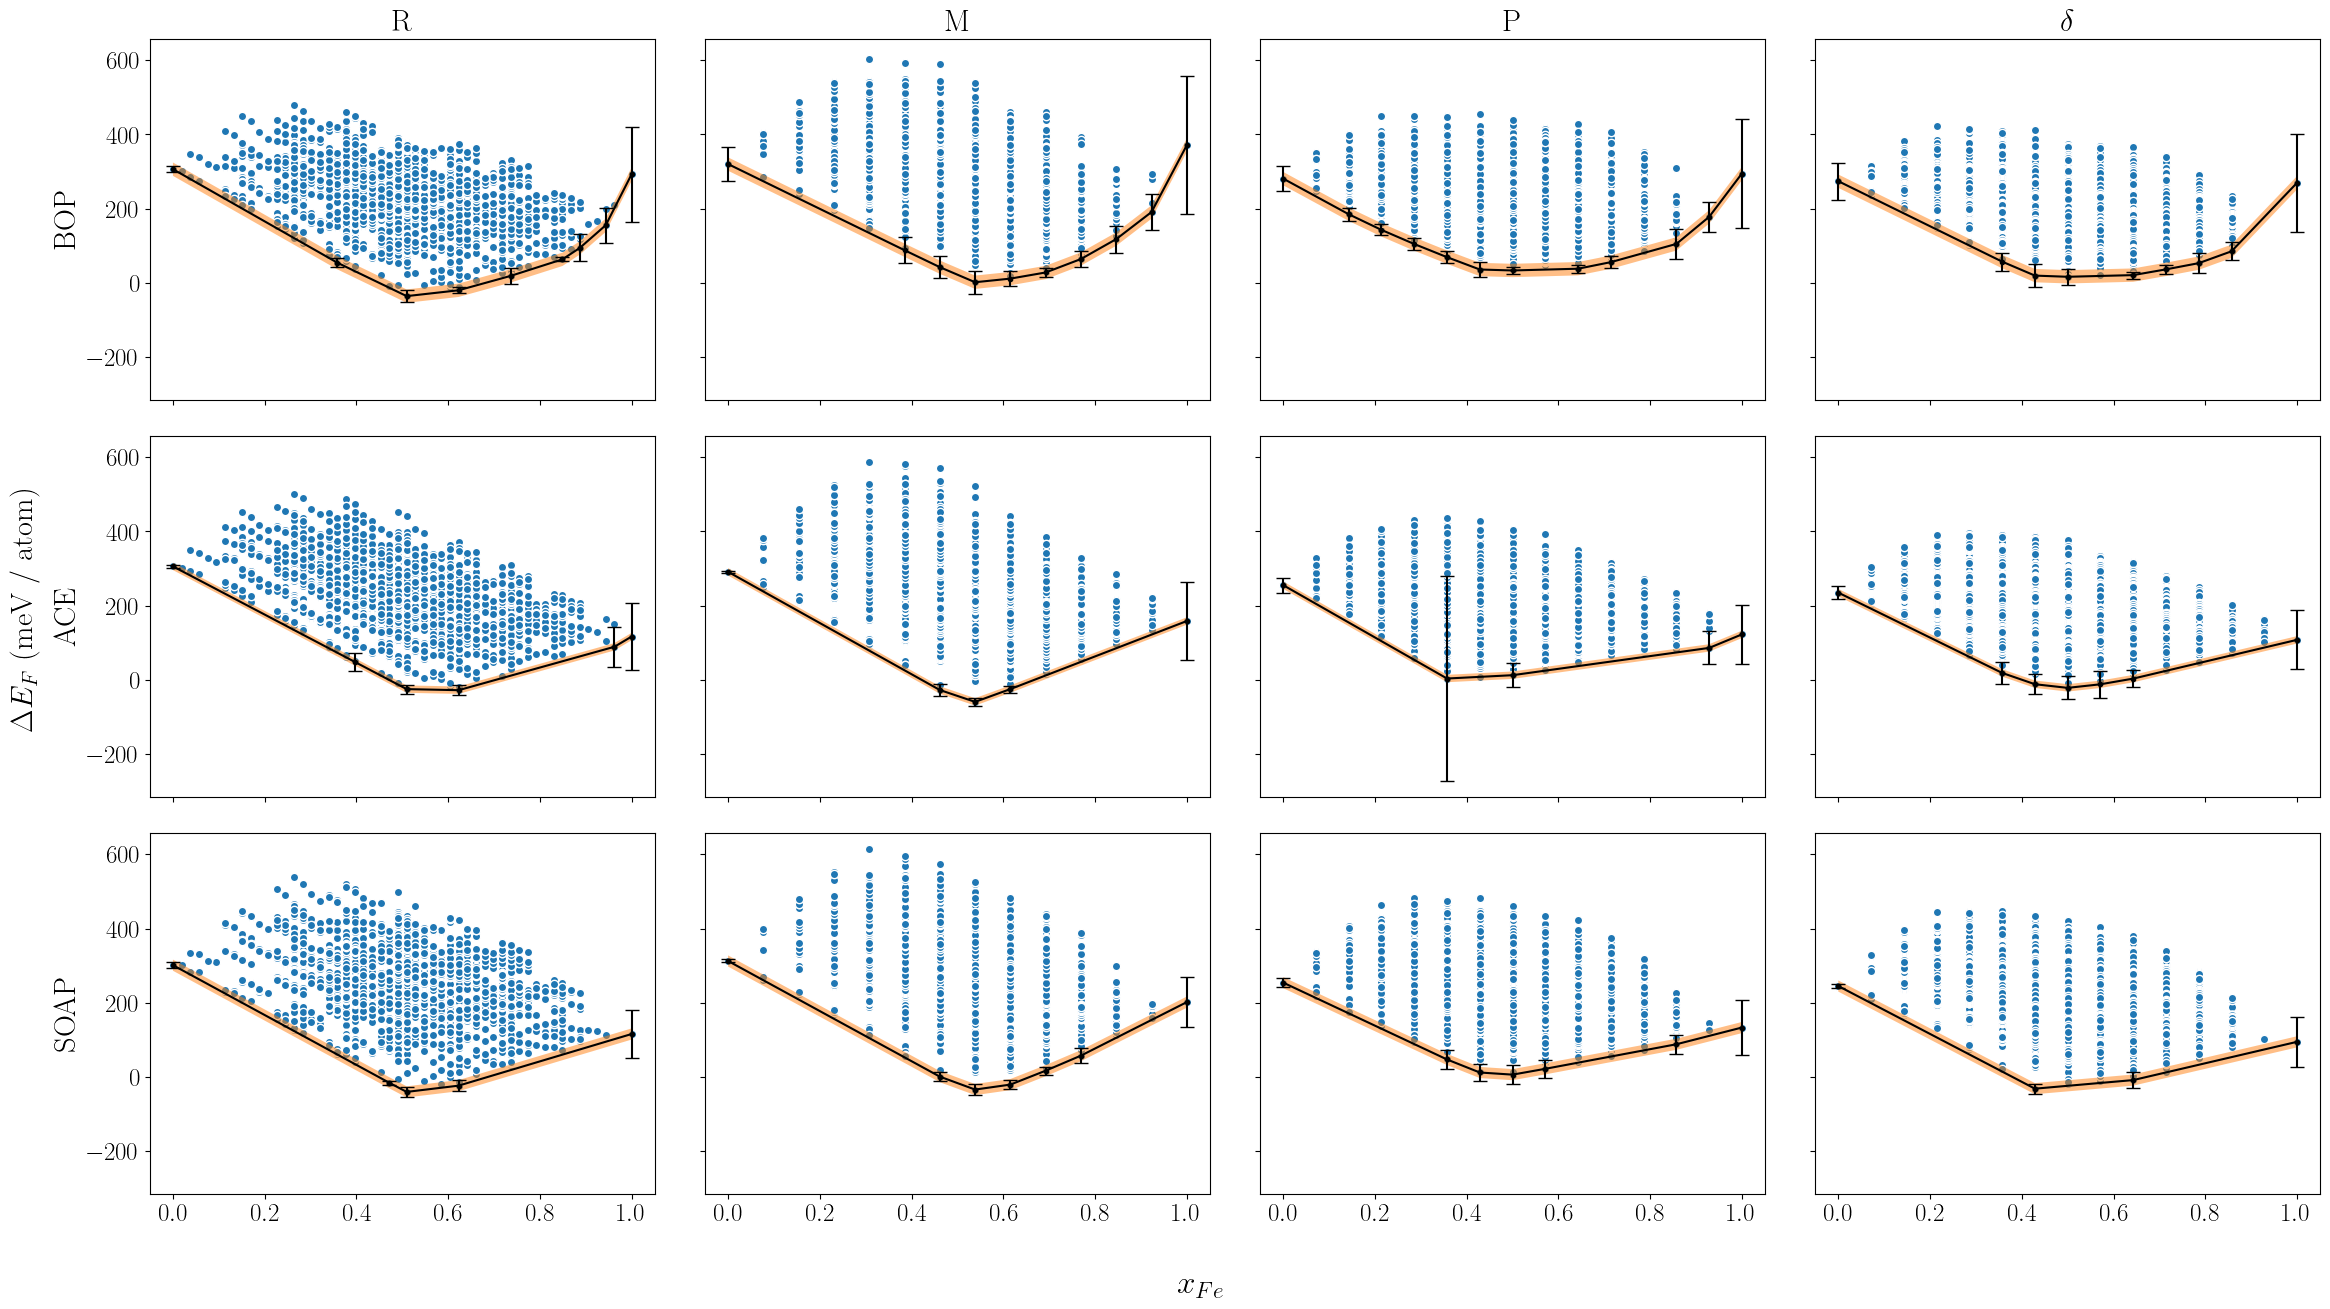

In [134]:
featurename_pos = {'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE',  'SOAP_specific_small': 'SOAP'}
test_errors = {'0.7dprojections_0.5os': 0.018, 'ACE':0.010, 'SOAP_specific_small': 0.015}#?
phase_pos = {'R': 0, 'M': 1, 'P': 2, 'delta': 3}#, 'M': 4}
#fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*2, plt.rcParams['figure.figsize'][1]), sharey = True)
ncols = int(len(phase_pos))
nrows = int(len(featurename_pos))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(plt.rcParams['figure.figsize'][0]*ncols,plt.rcParams['figure.figsize'][1]*nrows),
    sharey=True,
    sharex=True
    )
for featuregroup, I in featurename_pos.items():
    targetname = f'{target_case}__{featuregroup}'
    for phase, J in phase_pos.items():
        training_samples = BS.index.str.contains(f'\\.{phase}-')
        index1 = BS_predict[phase].index
        index2 = Accepted_Prediction_Values[(featuregroup, phase)].index
        intersection = index1.intersection(index2)
        targetname = f'{target_case}__{featuregroup}'
        this_chull = inchull[(phase, targetname)].index
        axes[I,J].scatter(BS_predict[phase]['Fe_pv'][intersection], Accepted_Prediction_Values[(featuregroup, phase)][targetname][intersection]*1000, label = 'Predictions', edgecolor='w')
        axes[I,J].plot(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            'k',
            label = 'convex hull'
            )
        axes[I,J].fill_between(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Accepted_Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 - test_errors[featuregroup]*1000, 
            Accepted_Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 + test_errors[featuregroup]*1000, 
            label = 'test error',
            alpha=0.5
            )
        axes[I,J].errorbar(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Accepted_Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            yerr= Prediction_Values[(featuregroup, phase)]['std_votes'][this_chull].values*1000,
            fmt='.k',
            capsize=5,
#            lolims=True,
            label = 'std from bag of predictions'
            )
        if len(training_samples) <0:
            continue
#        axes[I,J].scatter(
#            BS['Fe_pv'][training_samples],
#            BS[target_case][training_samples]*1000,
#            edgecolor='k',
#            label='DFT calculations',
#            s = 100
#            )
        axes[0, J].set_title(phase_label[phase], fontsize=22)
#    axes[0,I].legend( fontsize=plt.rcParams['font.size']*0.6,bbox_to_anchor = (1, 1),)
    axes[I,0].set_ylabel(featurename_label[featuregroup], fontsize=22)
fig.supxlabel('$x_{Fe}$', fontsize=24, y=0.04)
fig.subplots_adjust(hspace=0.1, wspace=0.1)
fig.supylabel(r'$\Delta E_F$ (meV / atom)', fontsize=22, x=0.075)
fig.savefig(f'{dataset}/graphs/{dataset}_R_{targetname}_convexhull.pdf')
#fig.supxlabel('$x_{Fe}$', y=-0.01)
#fig.supylabel (r'$\Delta E_F$ (meV / atom)')
#fig.legend([Line2D([0],[0], ))])

In [135]:
BOP_vs_ACE = (Prediction_Values[(bopmodel, 'R')][f'{target_case}__{bopmodel}'] - Prediction_Values[(acemodel, 'R')][f'{target_case}__{acemodel}']).abs()

## difference as function to distance to the hull

In [136]:
from scipy.spatial import Delaunay

In [137]:
xp = inchull[('R',f'{target_case}__{acemodel}')]['Fe_pv']
yp = inchull[('R',f'{target_case}__{acemodel}')][f'{target_case}__{acemodel}']

In [138]:
import pdb

In [139]:
def distance_to_chull(x, y,  chull_def: pd.core.series.Series, valuename : str):
    y_in_chull = np.interp(x, xp, yp,)
    return y - y_in_chull

In [140]:
targetname=f'{target_case}__ACE'
distance_to_chull(BS_predict['R']['Fe_pv']['Fe_pv53.R.NM'], Prediction_Values[(acemodel, 'R')][targetname]['Fe_pv53.R.NM'], inchull[('R',f'{target_case}__{acemodel}')], f'{target_case}__{acemodel}' )

0.0

In [141]:
xy = pd.concat([BS_predict['R']['Fe_pv'], Prediction_Values[(acemodel, 'R')][targetname]], axis = 1)

In [142]:
inchull['R', f'{target_case}__{acemodel}' ]

,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv53.R.NM,0.000000,1,0.306008
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,2,0.048849
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,2,-0.024561
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,2,-0.027469
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,0.962264,2,0.089447
Fe_pv53.R.NM,1.000000,1,0.117144


In [143]:
inchull['R', f'{target_case}__{acemodel}']

,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv53.R.NM,0.000000,1,0.306008
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,2,0.048849
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,2,-0.024561
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,2,-0.027469
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,0.962264,2,0.089447
Fe_pv53.R.NM,1.000000,1,0.117144


In [144]:
compound = xy.iloc[0]

In [145]:
distances_to_chull = {} # pd.Series([], name = 'DistanceToChull')
for index, compound in xy.iterrows():
    distances_to_chull[index] = distance_to_chull(compound['Fe_pv'], compound[targetname], inchull[('R', f'{target_case}__{acemodel}')], targetname)
distances_to_chull = pd.Series(distances_to_chull)

In [146]:
selection = xy.index.str.contains('NM')

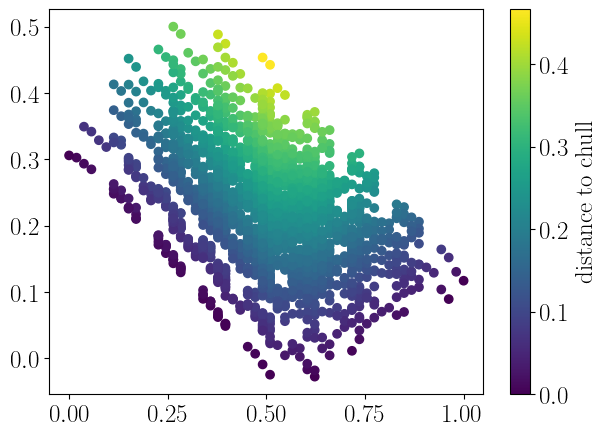

In [147]:
plt.scatter(xy['Fe_pv'][selection], xy[targetname][selection], c=distances_to_chull[selection])
plt.colorbar(label='distance to chull')

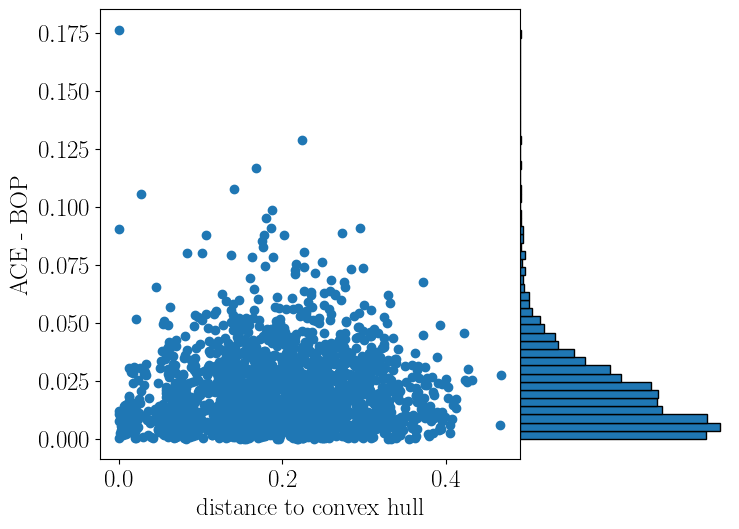

In [148]:
fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 0.6, 0.9])
ax2 = fig.add_axes([0.7, 0.1, 0.3,0.9], sharey = axes)
ax2.set_axis_off()
axes.scatter(distances_to_chull[selection], BOP_vs_ACE[selection])
hist = ax2.hist(BOP_vs_ACE[selection], orientation='horizontal', bins = 50,edgecolor='k')
axes.set_xlabel ('distance to convex hull')
axes.set_ylabel('ACE - BOP')
fig.savefig(f'{dataset}/graphs/{dataset}_error_vs_distance_to_chull.pdf')

Text(0.5, 1.0, 'Kernel Ridge / EF_nmhcp__ACE')

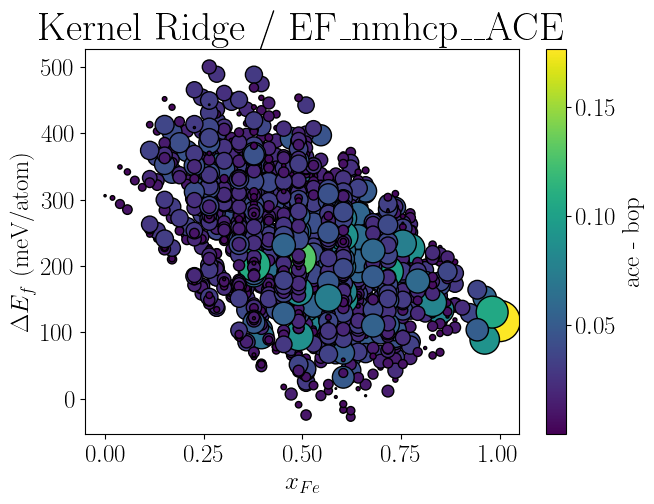

In [149]:
fig, axes = plt.subplots()
mapble = axes.scatter(xy['Fe_pv'], xy[targetname]*1000, c=BOP_vs_ACE, s=BOP_vs_ACE*5000, edgecolor='k')#c=distances_to_chull)
plt.colorbar(label='ace - bop', mappable=mapble)
axes.set_xlabel(r'$x_{Fe}$')
axes.set_ylabel(r'$\Delta E_f$ (meV/atom)')
axes.set_title(ModelName+' / '+targetname)

# Recover samples in convex hull for validation 

In [150]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [151]:
ValidationDataLocation

'Fe-Mo/data/Validation'

In [152]:
pd.concat(inchull, axis =0).to_csv(os.path.join(ValidationDataLocation, 'inchull.csv'))

In [153]:
if not os.path.exists(ValidationDataLocation):
    os.makedirs(ValidationDataLocation)
for (phase, target_name), inchullist in inchull.items():
    group_loc = os.path.join(ValidationDataLocation, 'inchull', phase)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    #inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['Atoms']['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, direct=True, format='vasp')
        validation_structure_location = validation_atoms_location.replace('vasp', 'cfg')
        atoms.write(validation_structure_location, format='cfg')

In [154]:
inchull[('delta', 'EF_nmhcp__ACE')]


,Fe_pv,nelem,EF_nmhcp__ACE
Mo_sv56.delta-BBBBBBBBBBBBBB.NM,0.000000,1,0.235321
Fe_pv20Mo_sv36.delta-BBBBBBBBABAAAA.NM,0.357143,2,0.019056
Fe_pv24Mo_sv32.delta-BBBBBBBBAAAAAA.NM,0.428571,2,-0.011371
Fe_pv28Mo_sv28.delta-BBBABBBBAAAAAA.NM,0.500000,2,-0.021200
Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM,0.571429,2,-0.011545
Fe_pv36Mo_sv20.delta-BBBAAABBAAAAAA.NM,0.642857,2,0.003752
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,1.000000,1,0.108180


In [155]:
for (phase, target_name), inchullist in opo_chull.items():
    group_loc = os.path.join(ValidationDataLocation, 'opochull', phase, target_name)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, format='vasp',sort=True)


In [156]:
inchull[('R','EF_nmhcp__0.7dprojections_0.5os' )].shape

(9, 3)

In [157]:
AtomsObjects[phase]['Atoms']['atoms'][inchullist.index]

Mo_sv56.delta-BBBBBBBBBBBBBB.NM           (Atom('Mo', [1.7119784720347544, 4.69216107593...
Fe_pv24Mo_sv32.delta-BBBBBBBBAAAAAA.NM    (Atom('Mo', [1.645442447939846, 4.509800288397...
Fe_pv36Mo_sv20.delta-BBBAABBAAAAAAA.NM    (Atom('Mo', [1.6100554815164523, 4.41281230101...
Fe_pv56.delta-AAAAAAAAAAAAAA.NM           (Atom('Fe', [1.5473619161942118, 4.24098285822...
Name: atoms, dtype: object